# Global Benchmark Analysis

This notebook performs comprehensive cross-benchmark analysis evaluating 4 key metrics across 3 benchmarks:
- **PubMedQA** (pubmedqa_new2): Baseline + Levels 1-6 (yes/no/maybe answers)
- **MedQA** (medqa): Baseline + Levels 1-6 (A/B/C/D answers)
- **MedMCQA** (medmcqa_2): Baseline + Levels 1-6 (A/B/C/D answers)

## Evaluation Points
1. Accuracy Under Structured Constraints**: How do structured constraints affect accuracy?
2. Output Validity and Schema Compliance**: How well do models follow structured schemas?
3.  Confidence and Calibration Behavior**: Are models well-calibrated? Does structure affect calibration?
4. Decision Distribution Shifts**: Do structured constraints change answer patterns?


In [1]:
# Import libraries
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Define paths for all 3 benchmarks
BASE_DIR = Path("/mloscratch/users/hatrouho/lm-evaluation-harness/results")
PUBMEDQA_DIR = BASE_DIR / "pubmedqa_new2"
MEDQA_DIR = BASE_DIR / "medqa"
MEDQA_BASELINE_DIR = BASE_DIR / "medqa_baseline"
MEDMCQA_DIR = BASE_DIR / "medmcqa_2"

# Create plots directory
PLOTS_DIR = BASE_DIR / "global_analysis" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(" Imports and paths configured")


 Imports and paths configured


## 1. Data Loading & Parsing


In [2]:
# Utility functions for loading data
def load_results(result_file: str) -> Dict[str, Any]:
    """Load result JSON file and extract metrics."""
    with open(result_file, 'r') as f:
        data = json.load(f)
    return data

def load_samples(samples_file: str) -> List[Dict[str, Any]]:
    """Load sample JSONL file."""
    samples = []
    with open(samples_file, 'r') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line))
    return samples

def extract_json_from_text(text: str) -> Optional[Dict]:
    """Extract JSON object from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

print(" Utility functions defined")


 Utility functions defined


In [3]:
# Diagnostic: Investigate JSON parsing issues for medqa
# This cell helps identify why medqa shows many invalid JSON responses

print("="*80)
print("DIAGNOSTIC: MedQA JSON Validity Investigation")
print("="*80)

import re

def analyze_json_validity(benchmark: str, level: str):
    """Analyze JSON validity issues for a specific benchmark/level."""
    if benchmark == 'medqa':
        if level == 'baseline':
            return  # Skip baseline
        sample_file_map = {
            'L1': 'samples_LEVEL1.jsonl',
            'L2': 'samples_LEVEL2.jsonl',
            'L3': 'samples_LEVEL3.jsonl',
            'L4': 'samples_LEVEL4.jsonl',
            'L5': 'samples_LEVEL5.jsonl',
            'L6': 'samples_LEVEL6.jsonl',
        }
        if level not in sample_file_map:
            return
        
        filepath = MEDQA_DIR / sample_file_map[level]
        if not filepath.exists():
            return
        
        samples = load_samples(str(filepath))
        
        total = len(samples)
        valid_json = 0
        truncated_json = 0  # Starts with { but missing closing }
        whitespace_only = 0  # Just whitespace/newlines
        other_invalid = 0
        truncated_with_answer = 0  # Truncated but has extractable answer
        
        for sample in samples:
            raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
            if not raw_resp or not isinstance(raw_resp, str):
                other_invalid += 1
                continue
            
            stripped = raw_resp.strip()
            
            # Check for whitespace-only responses
            if not stripped or stripped == '{' or (stripped.startswith('{') and len(stripped.replace(' ', '').replace('\n', '').replace('\t', '')) < 5):
                whitespace_only += 1
                continue
            
            # Try parsing with improved function
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                valid_json += 1
            else:
                # Check if it's truncated (starts with { but doesn't end with })
                if stripped.startswith('{') and not stripped.rstrip().endswith('}'):
                    truncated_json += 1
                    # Check if we can at least extract the answer field
                    if re.search(r'"answer"\s*:\s*"([A-D])"', raw_resp):
                        truncated_with_answer += 1
                else:
                    other_invalid += 1
        
        print(f"\n{level}:")
        print(f"  Total samples: {total}")
        print(f"  Valid JSON: {valid_json} ({valid_json/total*100:.1f}%)")
        print(f"  Truncated JSON (missing closing brace): {truncated_json} ({truncated_json/total*100:.1f}%)")
        if truncated_json > 0:
            print(f"    - Truncated with extractable answer: {truncated_with_answer} ({truncated_with_answer/truncated_json*100:.1f}%)")
        print(f"  Whitespace-only: {whitespace_only} ({whitespace_only/total*100:.1f}%)")
        print(f"  Other invalid: {other_invalid} ({other_invalid/total*100:.1f}%)")
        
        return {
            'level': level,
            'total': total,
            'valid_json': valid_json,
            'truncated_json': truncated_json,
            'whitespace_only': whitespace_only,
            'other_invalid': other_invalid,
            'truncated_with_answer': truncated_with_answer
        }

# Analyze all medqa levels
print("\nAnalyzing MedQA JSON validity issues...\n")
medqa_diagnostics = []
for level in ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']:
    result = analyze_json_validity('medqa', level)
    if result:
        medqa_diagnostics.append(result)

print("\n" + "="*80)
print("SUMMARY: The high invalid JSON rate in MedQA is primarily due to:")
print("  1. Truncated JSON responses (missing closing braces) - especially in L4 and L6")
print("  2. Whitespace-only responses (empty or nearly empty JSON objects)")
print("="*80)


DIAGNOSTIC: MedQA JSON Validity Investigation

Analyzing MedQA JSON validity issues...


L1:
  Total samples: 1273
  Valid JSON: 1251 (98.3%)
  Truncated JSON (missing closing brace): 0 (0.0%)
  Whitespace-only: 22 (1.7%)
  Other invalid: 0 (0.0%)

L2:
  Total samples: 1273
  Valid JSON: 1251 (98.3%)
  Truncated JSON (missing closing brace): 0 (0.0%)
  Whitespace-only: 22 (1.7%)
  Other invalid: 0 (0.0%)

L3:
  Total samples: 1273
  Valid JSON: 1197 (94.0%)
  Truncated JSON (missing closing brace): 36 (2.8%)
    - Truncated with extractable answer: 36 (100.0%)
  Whitespace-only: 22 (1.7%)
  Other invalid: 18 (1.4%)

L4:
  Total samples: 1273
  Valid JSON: 875 (68.7%)
  Truncated JSON (missing closing brace): 376 (29.5%)
    - Truncated with extractable answer: 376 (100.0%)
  Whitespace-only: 22 (1.7%)
  Other invalid: 0 (0.0%)

L5:
  Total samples: 1273
  Valid JSON: 1155 (90.7%)
  Truncated JSON (missing closing brace): 17 (1.3%)
    - Truncated with extractable answer: 17 (100.0%)
  

In [4]:
# Define file mappings for each benchmark
# PubMedQA: Baseline + Levels 1-6
pubmedqa_result_files = {
    'baseline': 'pubmedqa_baseline_2025-12-02T17-10-15.514633.json',
    'L1': 'pubmedqa_level1_2025-12-08T14-28-16.793274.json',
    'L2': 'pubmedqa_level2_2025-12-08T14-33-38.031833.json',
    'L3': 'pubmedqa_level3_2025-12-08T16-37-05.472225.json',
    'L3_inverted': 'pubmedqa_level3_inverted_2025-12-12T13-14-54.900999.json',
    'L4': 'pubmedqa_level4_2025-12-08T17-53-41.436382.json',
    'L5': 'pubmedqa_level5_2025-12-08T19-23-52.009458.json',
    'L6': 'pubmedqa_level6_2025-12-08T19-45-46.527366.json',
}

pubmedqa_sample_files = {
    'baseline': 'samples_pubmedqa_generation_baseline.jsonl',
    'L1': 'samples_pubmedqa_generation_L1.jsonl',
    'L2': 'samples_pubmedqa_generation_L2.jsonl',
    'L3': 'samples_pubmedqa_generation_L3.jsonl',
    'L3_inverted': 'samples_pubmedqa_generation_level3Inverted.jsonl',
    'L4': 'samples_pubmedqa_generation_L4.jsonl',
    'L5': 'samples_pubmedqa_generation_L5.jsonl',
    'L6': 'samples_pubmedqa_generation_L6.jsonl',
}

# MedQA: Baseline + Levels 1-6
medqa_result_files = {
    'baseline': 'medqa_baseline_REAL_Prompt.json',
    'L1': 'medqa4options_LEVEL1.json',
    'L2': 'medqa4options_LEVEL2.json',
    'L3': 'medqa4options_LEVEL3.json',
    'L3_inverted': 'medqa_inverted_cot_2025-12-12T15-31-19.422661.json',
    'L4': 'medqa4options_LEVEL4.json',
    'L5': 'medqa4options_LEVEL5.json',
    'L6': 'medqa4options_LEVEL6.json',
}

medqa_sample_files = {
    'baseline': 'samples_medqa_4options_generation_baseline_REAL_prompt.jsonl',
    'L1': 'samples_LEVEL1.jsonl',
    'L2': 'samples_LEVEL2.jsonl',
    'L3': 'samples_LEVEL3.jsonl',
    'L3_inverted': 'samples_INVERTED.jsonl',
    'L4': 'samples_LEVEL4.jsonl',
    'L5': 'samples_LEVEL5.jsonl',
    'L6': 'samples_LEVEL6.jsonl',
}

# MedMCQA: Baseline + Levels 1-6
medmcqa_result_files = {
    'baseline': 'False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json',
    'L1': 'medmcqa_level1_2025-12-08T18-49-34.939793.json',
    'L2': 'medmcqa_level2_2025-12-08T22-15-47.472224.json',
    'L3': 'medmcqa_level3_2025-12-10T02-51-09.353135.json',
    'L3_inverted': 'medmcqa_MCQInvertedCoTAnswer_2025-12-12T19-12-02.556477.json',
    'L4': 'medmcqa_level4_2025-12-10T17-18-56.377289.json',
    'L5': 'medmcqa_level5_2025-12-11T08-06-31.565470.json',
    'L6': 'medmcqa_level6_2025-12-11T21-30-51.473619.json',
}

medmcqa_sample_files = {
    'baseline': 'samples_medmcqa_generation_2025-12-11T08-21-06.604776.jsonl',
    'L1': 'samples_medmcqa_generation_2025-12-08T18-49-34.939793.jsonl',
    'L2': 'samples_medmcqa_generation_2025-12-08T22-15-47.472224.jsonl',
    'L3': 'samples_medmcqa_generation_2025-12-10T02-51-09.353135.jsonl',
    'L3_inverted': 'samples_medmcqa_generation_2025-12-12T19-12-02.556477.jsonl',
    'L4': 'samples_medmcqa_generation_2025-12-10T17-18-56.377289.jsonl',
    'L5': 'samples_medmcqa_generation_2025-12-11T08-06-31.565470.jsonl',
    'L6': 'samples_medmcqa_generation_2025-12-11T21-30-51.473619.jsonl',
}

print(" File mappings defined")


 File mappings defined


In [5]:
# Load all data
all_results = {}
all_samples = {}

# Load PubMedQA
print("Loading PubMedQA...")
all_results['pubmedqa'] = {}
all_samples['pubmedqa'] = {}
for level, filename in pubmedqa_result_files.items():
    filepath = PUBMEDQA_DIR / filename
    if filepath.exists():
        all_results['pubmedqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in pubmedqa_sample_files.items():
    filepath = PUBMEDQA_DIR / filename
    if filepath.exists():
        all_samples['pubmedqa'][level] = load_samples(str(filepath))
        print(f"   {level} samples: {len(all_samples['pubmedqa'][level])} samples")
    else:
        print(f"   Warning: {filename} not found")

# Load MedQA
print("\nLoading MedQA...")
all_results['medqa'] = {}
all_samples['medqa'] = {}
for level, filename in medqa_result_files.items():
    # Baseline is in medqa_baseline directory, L1-L6 are in medqa directory
    if level == 'baseline':
        filepath = MEDQA_BASELINE_DIR / filename
    else:
        filepath = MEDQA_DIR / filename
    if filepath.exists():
        all_results['medqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in medqa_sample_files.items():
    # Baseline is in medqa_baseline directory, L1-L6 are in medqa directory
    if level == 'baseline':
        filepath = MEDQA_BASELINE_DIR / filename
    else:
        filepath = MEDQA_DIR / filename
    if filepath.exists():
        all_samples['medqa'][level] = load_samples(str(filepath))
        print(f"  ✓ {level} samples: {len(all_samples['medqa'][level])} samples")
    else:
        print(f"  ✗ Warning: {filename} not found")

# Load MedMCQA
print("\nLoading MedMCQA...")
all_results['medmcqa'] = {}
all_samples['medmcqa'] = {}
for level, filename in medmcqa_result_files.items():
    filepath = MEDMCQA_DIR / filename
    if filepath.exists():
        all_results['medmcqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in medmcqa_sample_files.items():
    filepath = MEDMCQA_DIR / filename
    if filepath.exists():
        all_samples['medmcqa'][level] = load_samples(str(filepath))
        print(f"   {level} samples: {len(all_samples['medmcqa'][level])} samples")
    else:
        print(f"   Warning: {filename} not found")

print(f"\n Data loading complete")


Loading PubMedQA...
   baseline: pubmedqa_baseline_2025-12-02T17-10-15.514633.json
   L1: pubmedqa_level1_2025-12-08T14-28-16.793274.json
   L2: pubmedqa_level2_2025-12-08T14-33-38.031833.json
   L3: pubmedqa_level3_2025-12-08T16-37-05.472225.json
   L3_inverted: pubmedqa_level3_inverted_2025-12-12T13-14-54.900999.json
   L4: pubmedqa_level4_2025-12-08T17-53-41.436382.json
   L5: pubmedqa_level5_2025-12-08T19-23-52.009458.json
   L6: pubmedqa_level6_2025-12-08T19-45-46.527366.json
   baseline samples: 500 samples
   L1 samples: 500 samples
   L2 samples: 500 samples
   L3 samples: 500 samples
   L3_inverted samples: 500 samples
   L4 samples: 500 samples
   L5 samples: 500 samples
   L6 samples: 500 samples

Loading MedQA...
   baseline: medqa_baseline_REAL_Prompt.json
   L1: medqa4options_LEVEL1.json
   L2: medqa4options_LEVEL2.json
   L3: medqa4options_LEVEL3.json
   L3_inverted: medqa_inverted_cot_2025-12-12T15-31-19.422661.json
   L4: medqa4options_LEVEL4.json
   L5: medqa4options_

In [6]:
# Unified parsing function for all benchmarks
def parse_sample(sample: Dict, level: str, benchmark: str) -> Dict[str, Any]:
    """Parse a sample based on schema level with comprehensive extraction.
    
    Args:
        sample: Sample dictionary from JSONL
        level: Schema level (baseline, L1-L6)
        benchmark: Benchmark name (pubmedqa, medqa, medmcqa)
    """
    raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
    filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
    target = sample.get('target', '')
    exact_match = sample.get('exact_match', 0)
    doc_id = sample.get('doc_id', -1)
    
    # Determine valid answers based on benchmark
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
        answer_normalize = lambda x: x.lower().strip() if x else '[invalid]'
    else:  # medqa, medmcqa
        valid_answers = ['A', 'B', 'C', 'D']
        answer_normalize = lambda x: x.upper().strip() if x else '[invalid]'
    
    parsed_data = {
        'benchmark': benchmark,
        'level': level,
        'doc_id': doc_id,
        'raw_response': raw_resp if raw_resp else '',
        'filtered_response': filtered_resp if filtered_resp else '[invalid]',
        'target': target,
        'exact_match': exact_match,
        'json_valid': False,
        'answer': None,
        'confidence': None,
        'probabilities': None,
        'reasoning': None,
        'justification': None,
        'eliminated': None,
        'key_evidence': None,
        'key_concepts': None,
        'has_answer': False,
        'has_confidence': False,
        'has_probabilities': False,
        'has_reasoning': False,
        'has_justification': False,
        'has_eliminated': False,
        'has_key_evidence': False,
        'has_key_concepts': False,
        'confidence_valid': False,
        'schema_compliant': False,
    }
    
    # Baseline: extract from free-form text
    if level == 'baseline':
        answer = answer_normalize(filtered_resp)
        if answer in valid_answers:
            parsed_data['answer'] = answer
            parsed_data['has_answer'] = True
        else:
            parsed_data['answer'] = '[invalid]'
        parsed_data['schema_compliant'] = parsed_data['has_answer']
        return parsed_data
    
    # Schema levels: parse JSON
    if raw_resp and isinstance(raw_resp, str):
        parsed_json = extract_json_from_text(raw_resp)
        if parsed_json and isinstance(parsed_json, dict):
            parsed_data['json_valid'] = True
            answer = answer_normalize(parsed_json.get('answer', ''))
            parsed_data['answer'] = answer
            parsed_data['has_answer'] = answer in valid_answers
            
            # Extract confidence
            if 'confidence' in parsed_json:
                try:
                    conf = float(parsed_json['confidence'])
                    parsed_data['confidence'] = conf
                    parsed_data['has_confidence'] = True
                    parsed_data['confidence_valid'] = (0.0 <= conf <= 1.0)
                except (ValueError, TypeError):
                    pass
            
            
            
            # Extract reasoning/justification
            parsed_data['reasoning'] = parsed_json.get('reasoning', '')
            parsed_data['justification'] = parsed_json.get('justification', '')
            parsed_data['has_reasoning'] = bool(parsed_data['reasoning'])
            parsed_data['has_justification'] = bool(parsed_data['justification'])
            
            # Extract eliminated options (Level 5)
            parsed_data['eliminated'] = parsed_json.get('eliminated', [])
            parsed_data['has_eliminated'] = isinstance(parsed_data['eliminated'], list) and len(parsed_data['eliminated']) > 0
            
            # Extract key evidence (Level 5)
            parsed_data['key_evidence'] = parsed_json.get('key_evidence', '')
            parsed_data['has_key_evidence'] = bool(parsed_data['key_evidence'])
            
            # Extract key concepts (Level 6)
            parsed_data['key_concepts'] = parsed_json.get('key_concepts', [])
            parsed_data['has_key_concepts'] = isinstance(parsed_data['key_concepts'], list) and len(parsed_data['key_concepts']) > 0
            
            # Check schema compliance based on level
            if level == 'L1':
                parsed_data['schema_compliant'] = parsed_data['json_valid'] and parsed_data['has_answer']
            elif level == 'L2':
                if benchmark == 'pubmedqa':
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid'])
                else:  # medqa, medmcqa
                    # MCQ L2: answer + confidence (required) - NO probabilities required for standard schema
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid'])
            elif level == 'L3':
                if benchmark == 'pubmedqa':
                    # PubMedQA L3: answer + reasoning (required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_reasoning'])
                else:  # medqa, medmcqa
                    # MCQ L3: answer + justification (required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_justification'])
            elif level == 'L3_inverted':
                # L3_inverted: answer + reasoning (required) - same for all benchmarks
                # Note: MCQ L3 uses justification, but L3_inverted uses reasoning
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'])
            elif level == 'L4':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                   and parsed_data['confidence_valid'])
            elif level == 'L5':
                if benchmark == 'pubmedqa':
                    # PubMedQA L5: answer + confidence + reasoning + key_evidence (all required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid']
                                                       and parsed_data['has_reasoning'] and parsed_data['has_key_evidence'])
                else:  # medqa, medmcqa
                    # MCQ L5: answer + eliminated + key_evidence
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_eliminated'] and parsed_data['has_key_evidence'])
            elif level == 'L6':
                if benchmark == 'pubmedqa':
                    # PubMedQA L6: answer + optional fields (all optional except answer)
                    # Compliance: just need valid JSON with answer
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'])
                else:  # medqa, medmcqa
                    # MCQ L6: answer + reasoning + confidence + key_concepts
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                       and parsed_data['confidence_valid'] and parsed_data['has_key_concepts'])
        else:
            # Fallback to filtered response
            answer = answer_normalize(filtered_resp)
            if answer in valid_answers:
                parsed_data['answer'] = answer
                parsed_data['has_answer'] = True
            else:
                parsed_data['answer'] = '[invalid]'
    
    return parsed_data

# Parse all samples
all_parsed = {}
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    all_parsed[benchmark] = {}
    for level in all_samples[benchmark].keys():
        all_parsed[benchmark][level] = [
            parse_sample(s, level, benchmark) for s in all_samples[benchmark][level]
        ]
        print(f"✓ Parsed {benchmark} {level}: {len(all_parsed[benchmark][level])} samples")

print("\n All samples parsed")


✓ Parsed pubmedqa baseline: 500 samples
✓ Parsed pubmedqa L1: 500 samples
✓ Parsed pubmedqa L2: 500 samples
✓ Parsed pubmedqa L3: 500 samples
✓ Parsed pubmedqa L3_inverted: 500 samples
✓ Parsed pubmedqa L4: 500 samples
✓ Parsed pubmedqa L5: 500 samples
✓ Parsed pubmedqa L6: 500 samples
✓ Parsed medqa baseline: 1273 samples
✓ Parsed medqa L1: 1273 samples
✓ Parsed medqa L2: 1273 samples
✓ Parsed medqa L3: 1273 samples
✓ Parsed medqa L3_inverted: 1273 samples
✓ Parsed medqa L4: 1273 samples
✓ Parsed medqa L5: 1273 samples
✓ Parsed medqa L6: 1273 samples
✓ Parsed medmcqa baseline: 4183 samples
✓ Parsed medmcqa L1: 4183 samples
✓ Parsed medmcqa L2: 4183 samples
✓ Parsed medmcqa L3: 4183 samples
✓ Parsed medmcqa L3_inverted: 4183 samples
✓ Parsed medmcqa L4: 4183 samples
✓ Parsed medmcqa L5: 4183 samples
✓ Parsed medmcqa L6: 4183 samples

 All samples parsed


## 4.1 Accuracy Under Structured Constraints

This section analyzes how structured constraints affect model accuracy across different benchmarks and schema levels.


In [7]:
# Extract accuracy metrics from results and parsed samples
accuracy_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        # Get accuracy from results file if available
        if level in all_results[benchmark]:
            result = all_results[benchmark][level]
            # Extract task name (varies by benchmark)
            task_key = None
            for key in result.get('results', {}).keys():
                if 'generation' in key or 'pubmedqa' in key or 'medqa' in key or 'medmcqa' in key:
                    task_key = key
                    break
            
            if task_key:
                exact_match = result['results'][task_key].get('exact_match,strict-match', 0)
                exact_match_stderr = result['results'][task_key].get('exact_match_stderr,strict-match', 0)
            else:
                exact_match = 0
                exact_match_stderr = 0
        else:
            # Calculate from parsed samples
            parsed = all_parsed[benchmark][level]
            exact_match = np.mean([p['exact_match'] for p in parsed])
            exact_match_stderr = np.std([p['exact_match'] for p in parsed]) / np.sqrt(len(parsed))
        
        # Also calculate from parsed samples for consistency
        parsed = all_parsed[benchmark][level]
        accuracy_from_samples = np.mean([p['exact_match'] for p in parsed])
        
        accuracy_data.append({
            'benchmark': benchmark,
            'level': level,
            'accuracy': exact_match,
            'accuracy_stderr': exact_match_stderr,
            'accuracy_from_samples': accuracy_from_samples,
            'n_samples': len(parsed)
        })

accuracy_df = pd.DataFrame(accuracy_data)
print("Accuracy data extracted:")
print(accuracy_df.groupby('benchmark')['level'].count())


Accuracy data extracted:
benchmark
medmcqa     8
medqa       8
pubmedqa    8
Name: level, dtype: int64


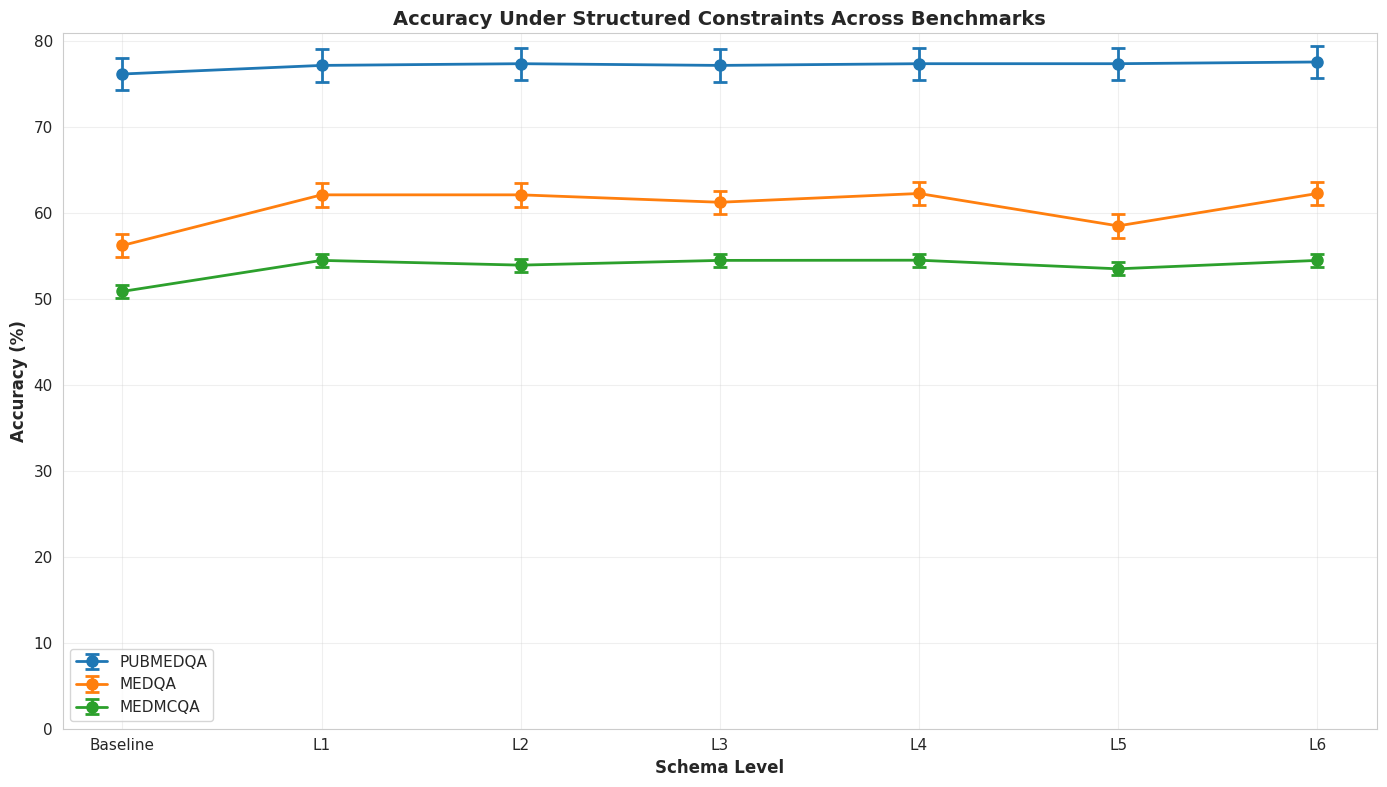

In [8]:
# Create accuracy comparison visualizations

# 1. Multi-benchmark accuracy comparison (line plot with error bars)
fig, ax = plt.subplots(figsize=(14, 8))

# Define level order
level_order = ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
level_labels = ['Baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    # Filter to available levels and sort
    bench_data = bench_data[bench_data['level'].isin(level_order)]
    bench_data['level_num'] = bench_data['level'].map({l: i for i, l in enumerate(level_order) if l in bench_data['level'].values})
    bench_data = bench_data.sort_values('level_num')
    
    x_pos = bench_data['level_num'].values
    y_vals = bench_data['accuracy'].values * 100
    y_err = bench_data['accuracy_stderr'].values * 100
    
    ax.errorbar(x_pos, y_vals, yerr=y_err, marker='o', linewidth=2, 
                markersize=8, label=benchmark.upper(), capsize=5, capthick=2)

ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Under Structured Constraints Across Benchmarks', fontsize=14, fontweight='bold')
ax.set_xticks(range(len([l for l in level_order if l in accuracy_df['level'].values])))
ax.set_xticklabels([l for l in level_labels if l.replace('Baseline', 'baseline') in accuracy_df['level'].values])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


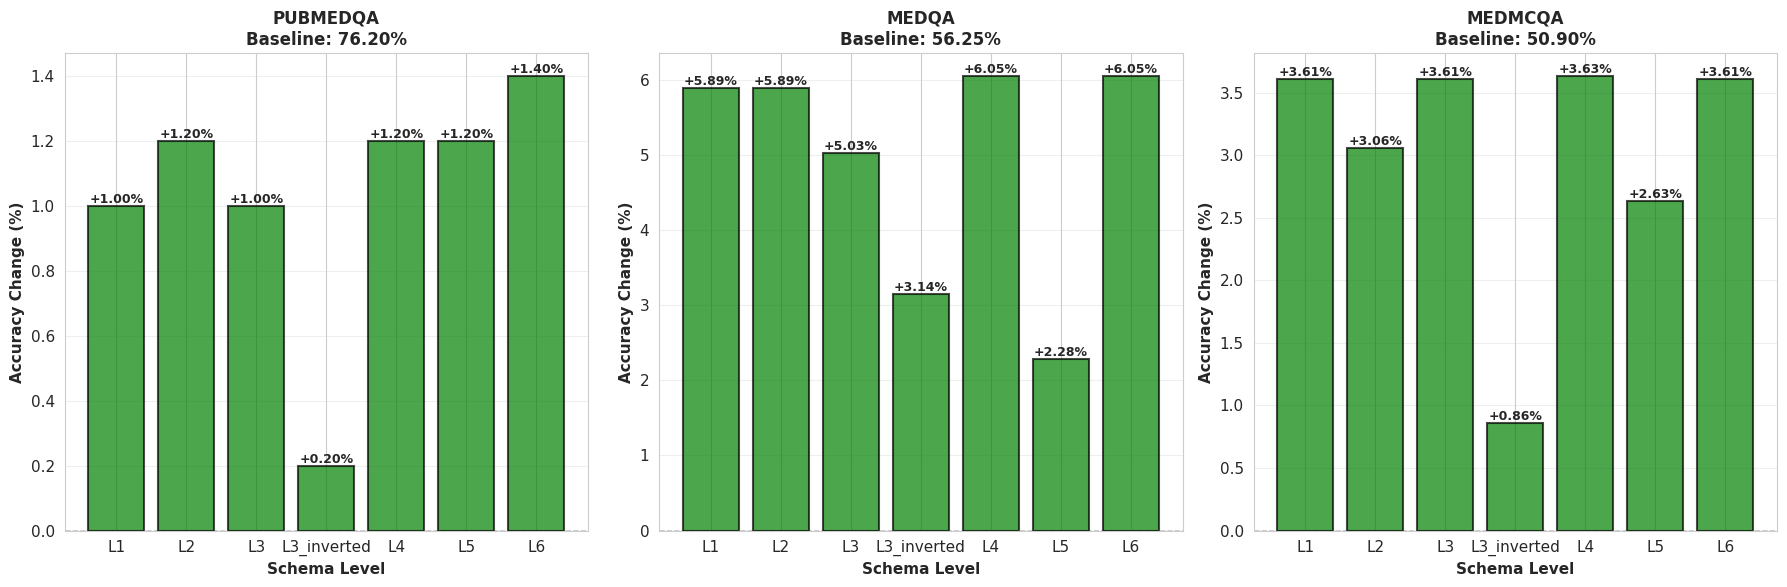

In [9]:
# 2. Accuracy change from baseline (bar chart)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
benchmarks = ['pubmedqa', 'medqa', 'medmcqa']

for idx, benchmark in enumerate(benchmarks):
    ax = axes[idx]
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    
    # Get baseline accuracy
    baseline_data = bench_data[bench_data['level'] == 'baseline']
    if len(baseline_data) > 0:
        baseline_acc = baseline_data['accuracy'].values[0] * 100
    else:
        # For pubmedqa, use L1 as reference
        baseline_acc = bench_data[bench_data['level'] == 'L1']['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == 'L1']) > 0 else 0
    
    # Calculate change from baseline
    bench_data = bench_data[bench_data['level'] != 'baseline']
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    changes = (bench_data['accuracy'].values * 100) - baseline_acc
    
    colors = ['green' if c > 0 else 'red' for c in changes]
    bars = ax.bar(levels, changes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy Change (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nBaseline: {baseline_acc:.2f}%', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, change in zip(bars, changes):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{change:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_change_from_baseline.png', dpi=300, bbox_inches='tight')
plt.show()


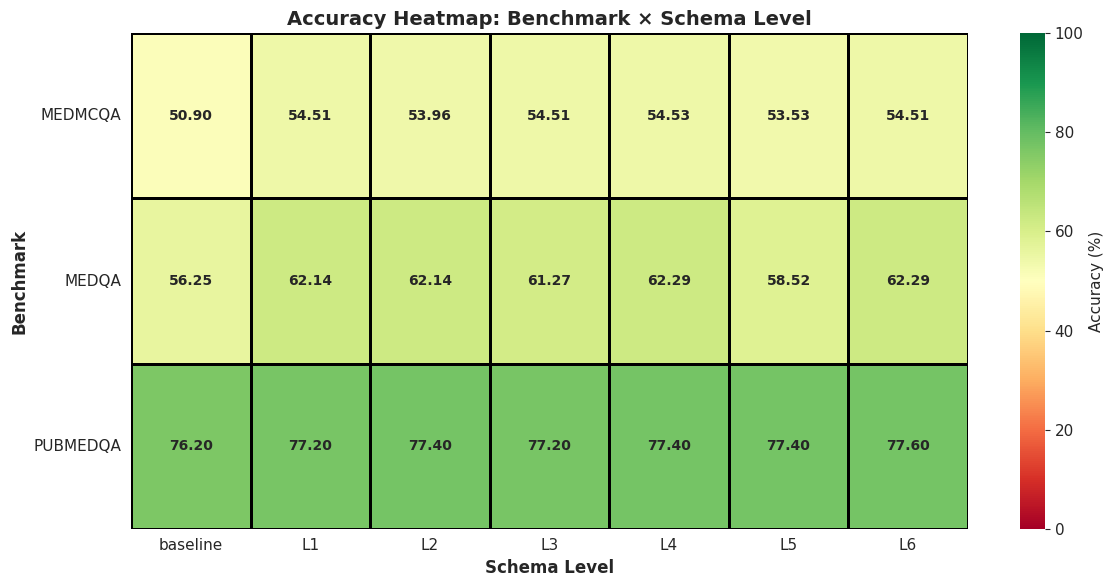

In [10]:
# 3. Heatmap showing accuracy by benchmark and level
pivot_data = accuracy_df.pivot(index='benchmark', columns='level', values='accuracy') * 100

# Reorder columns
level_order_available = [l for l in level_order if l in pivot_data.columns]
pivot_data = pivot_data[level_order_available]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Accuracy (%)'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Heatmap: Benchmark × Schema Level', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in pivot_data.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
# 4. Statistical significance tests between levels
print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS: Accuracy Differences Between Levels")
print("="*80)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    print(f"\n{benchmark.upper()}:")
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    levels = sorted(bench_data['level'].unique())
    
    # Get sample-level accuracy data for statistical tests
    bench_parsed = {}
    for level in levels:
        parsed = all_parsed[benchmark][level]
        bench_parsed[level] = [p['exact_match'] for p in parsed]
    
    # Compare each level with baseline (or L1 for pubmedqa)
    reference = 'baseline' if 'baseline' in levels else 'L1'
    if reference not in bench_parsed:
        continue
    
    ref_acc = np.array(bench_parsed[reference])
    
    for level in levels:
        if level == reference:
            continue
        level_acc = np.array(bench_parsed[level])
        
        # Perform t-test
        t_stat, p_value = stats.ttest_rel(ref_acc, level_acc) if len(ref_acc) == len(level_acc) else stats.ttest_ind(ref_acc, level_acc)
        
        mean_diff = np.mean(level_acc) - np.mean(ref_acc)
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        print(f"  {reference} vs {level}: Δ = {mean_diff*100:+.2f}%, p = {p_value:.4f} {significance}")

print("="*80)


STATISTICAL SIGNIFICANCE TESTS: Accuracy Differences Between Levels

PUBMEDQA:
  baseline vs L1: Δ = +1.00%, p = 0.4463 
  baseline vs L2: Δ = +1.20%, p = 0.3769 
  baseline vs L3: Δ = +1.00%, p = 0.4463 
  baseline vs L3_inverted: Δ = +0.20%, p = 0.8966 
  baseline vs L4: Δ = +1.20%, p = 0.3769 
  baseline vs L5: Δ = +1.20%, p = 0.3662 
  baseline vs L6: Δ = +1.40%, p = 0.2972 

MEDQA:
  baseline vs L1: Δ = +5.89%, p = 0.0000 ***
  baseline vs L2: Δ = +5.89%, p = 0.0000 ***
  baseline vs L3: Δ = +5.03%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +3.14%, p = 0.0281 *
  baseline vs L4: Δ = +6.05%, p = 0.0000 ***
  baseline vs L5: Δ = +2.28%, p = 0.0596 
  baseline vs L6: Δ = +6.05%, p = 0.0000 ***

MEDMCQA:
  baseline vs L1: Δ = +3.61%, p = 0.0000 ***
  baseline vs L2: Δ = +3.06%, p = 0.0000 ***
  baseline vs L3: Δ = +3.61%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +0.86%, p = 0.2860 
  baseline vs L4: Δ = +3.63%, p = 0.0000 ***
  baseline vs L5: Δ = +2.63%, p = 0.0002 ***
  bas

## 4.2 Output Validity and Schema Compliance

This section analyzes how well models follow structured schemas, including:
1. **JSON Validity Rates (Parseable Answer Rates)**: For baseline, this measures the rate of parseable answers extracted from text. For schema levels, this measures the rate of valid JSON that can be parsed.
2. **Conditional Schema Compliance**: Among samples with valid JSON, the percentage that are schema-compliant.
3. **Compliance Breakdown**: Stacked visualization showing Valid JSON + Compliant, Valid JSON + Non-Compliant, and Invalid JSON categories across all levels.


In [12]:
# Compute compliance metrics
compliance_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        
        n_total = len(parsed)
        n_json_valid = sum(1 for p in parsed if p['json_valid'])
        n_schema_compliant = sum(1 for p in parsed if p['schema_compliant'])
        n_has_answer = sum(1 for p in parsed if p['has_answer'])
        n_invalid_answer = sum(1 for p in parsed if p['answer'] == '[invalid]')
        n_has_confidence = sum(1 for p in parsed if p['has_confidence'])
        n_has_reasoning = sum(1 for p in parsed if p['has_reasoning'])
        n_has_justification = sum(1 for p in parsed if p['has_justification'])
        n_has_eliminated = sum(1 for p in parsed if p['has_eliminated'])
        n_has_key_evidence = sum(1 for p in parsed if p['has_key_evidence'])
        n_has_key_concepts = sum(1 for p in parsed if p['has_key_concepts'])
        
        # Compute parseable answer rate
        # For baseline: has_answer=True (answers extracted from text)
        # For schema levels: json_valid=True (valid JSON that can be parsed)
        if level == 'baseline':
            n_parseable = n_has_answer
        else:
            n_parseable = n_json_valid
        
        # Compute conditional schema compliance rate (within valid JSON)
        # Only for schema levels, not baseline
        if level != 'baseline' and n_json_valid > 0:
            schema_compliant_given_valid_json = n_schema_compliant / n_json_valid
        else:
            schema_compliant_given_valid_json = np.nan
        
        # Compute categories for stacked bar plot
        if level == 'baseline':
            # For baseline: use has_answer instead of json_valid
            # Valid + Compliant = has_answer=True (since schema_compliant = has_answer for baseline)
            # Invalid = has_answer=False
            n_valid_json_compliant = sum(1 for p in parsed if p['has_answer'] and p['schema_compliant'])
            n_valid_json_non_compliant = sum(1 for p in parsed if p['has_answer'] and not p['schema_compliant'])
            n_invalid_json = sum(1 for p in parsed if not p['has_answer'])
        else:
            # For schema levels: use json_valid
            n_valid_json_compliant = sum(1 for p in parsed if p['json_valid'] and p['schema_compliant'])
            n_valid_json_non_compliant = sum(1 for p in parsed if p['json_valid'] and not p['schema_compliant'])
            n_invalid_json = n_total - n_json_valid
        
        compliance_data.append({
            'benchmark': benchmark,
            'level': level,
            'n_total': n_total,
            'json_valid_rate': n_json_valid / n_total if n_total > 0 else 0,
            'schema_compliant_rate': n_schema_compliant / n_total if n_total > 0 else 0,
            'parseable_answer_rate': n_parseable / n_total if n_total > 0 else 0,
            'schema_compliant_rate_given_valid_json': schema_compliant_given_valid_json,
            'has_answer_rate': n_has_answer / n_total if n_total > 0 else 0,
            'invalid_answer_rate': n_invalid_answer / n_total if n_total > 0 else 0,
            'has_confidence_rate': n_has_confidence / n_total if n_total > 0 else 0,
            'has_reasoning_rate': n_has_reasoning / n_total if n_total > 0 else 0,
            'has_justification_rate': n_has_justification / n_total if n_total > 0 else 0,
            'has_eliminated_rate': n_has_eliminated / n_total if n_total > 0 else 0,
            'has_key_evidence_rate': n_has_key_evidence / n_total if n_total > 0 else 0,
            'has_key_concepts_rate': n_has_key_concepts / n_total if n_total > 0 else 0,
            # For stacked bar plot
            'n_valid_json_compliant': n_valid_json_compliant,
            'n_valid_json_non_compliant': n_valid_json_non_compliant,
            'n_invalid_json': n_invalid_json,
            'rate_valid_json_compliant': n_valid_json_compliant / n_total if n_total > 0 else 0,
            'rate_valid_json_non_compliant': n_valid_json_non_compliant / n_total if n_total > 0 else 0,
            'rate_invalid_json': n_invalid_json / n_total if n_total > 0 else 0,
        })

compliance_df = pd.DataFrame(compliance_data)
print("Compliance metrics computed")
print(compliance_df.groupby('benchmark')[['json_valid_rate', 'schema_compliant_rate']].mean())


Compliance metrics computed
           json_valid_rate  schema_compliant_rate
benchmark                                        
medmcqa           0.775341               0.884921
medqa             0.763060               0.855165
pubmedqa          0.834250               0.958500


In [13]:
# Display JSON validity rates (parseable answer rates) and conditional schema compliance
print("="*100)
print("JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE")
print("="*100)
print("\nFor baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)")
print("For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)")
print("Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON\n")

# Create summary table
summary_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        parseable_rate = row['parseable_answer_rate'] * 100
        json_valid_rate = row['json_valid_rate'] * 100
        schema_compliant_rate = row['schema_compliant_rate'] * 100
        
        # Conditional compliance (only for schema levels)
        if level != 'baseline' and not pd.isna(row['schema_compliant_rate_given_valid_json']):
            conditional_compliance = row['schema_compliant_rate_given_valid_json'] * 100
            conditional_str = f"{conditional_compliance:.2f}%"
        else:
            conditional_str = "N/A"
        
        summary_data.append({
            'Benchmark': benchmark.upper(),
            'Level': level,
            'Parseable Answer Rate (%)': f"{parseable_rate:.2f}",
            'JSON Valid Rate (%)': f"{json_valid_rate:.2f}",
            'Schema Compliant Rate (%)': f"{schema_compliant_rate:.2f}",
            'Schema Compliant (within Valid JSON) (%)': conditional_str
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*100)


JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE

For baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)
For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)
Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON

Benchmark       Level Parseable Answer Rate (%) JSON Valid Rate (%) Schema Compliant Rate (%) Schema Compliant (within Valid JSON) (%)
 PUBMEDQA          L1                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L2                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L3                     97.60               97.60                     97.60                                  100.00%
 PUBMEDQA L3_inverted                     95.80               95.80                     95.80            

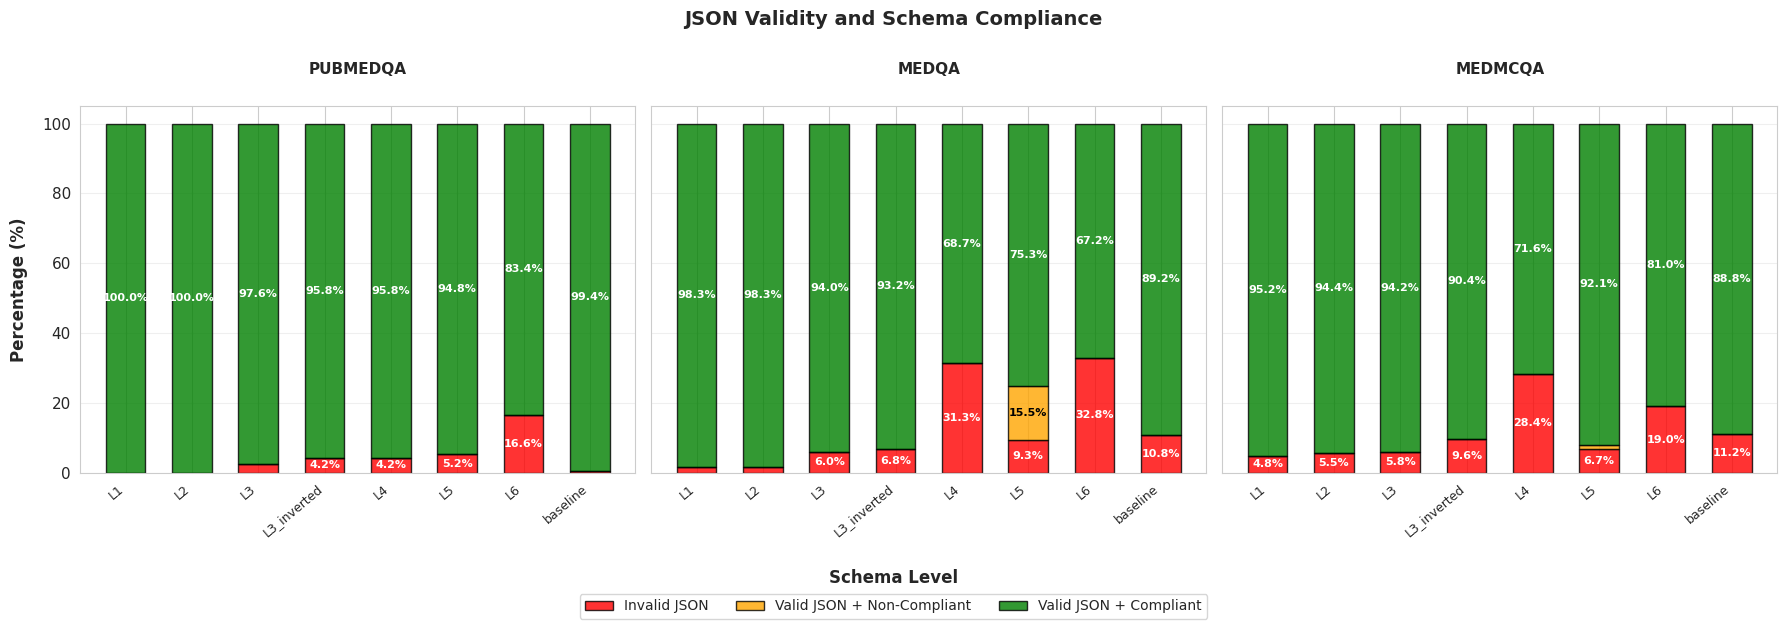

In [14]:
# 1. Stacked bar chart: Valid JSON + Compliant, Valid JSON + Non-Compliant, Invalid JSON
# Create subplots with shared axes - increase height to accommodate all elements
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Single title for all subplots - vertically centered above subplots
fig.suptitle('JSON Validity and Schema Compliance', fontsize=14, fontweight='bold', y=0.9)

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    # Get rates as percentages
    rate_invalid_json = bench_data['rate_invalid_json'].values * 100
    rate_valid_json_non_compliant = bench_data['rate_valid_json_non_compliant'].values * 100
    rate_valid_json_compliant = bench_data['rate_valid_json_compliant'].values * 100
    
    x = np.arange(len(levels))
    width = 0.6
    
    # Stack bars from bottom to top: Invalid JSON (bottom), Valid JSON + Non-Compliant (middle), Valid JSON + Compliant (top)
    bars1 = ax.bar(x, rate_invalid_json, width, label='Invalid JSON', alpha=0.8, color='red', edgecolor='black', linewidth=1)
    bars2 = ax.bar(x, rate_valid_json_non_compliant, width, bottom=rate_invalid_json, 
                   label='Valid JSON + Non-Compliant', alpha=0.8, color='orange', edgecolor='black', linewidth=1)
    bars3 = ax.bar(x, rate_valid_json_compliant, width, 
                   bottom=rate_invalid_json + rate_valid_json_non_compliant,
                   label='Valid JSON + Compliant', alpha=0.8, color='green', edgecolor='black', linewidth=1)
    
    # Only show y-axis label on left subplot (first one)
    if idx == 0:
        ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', labelpad=10)
    
    # Add benchmark label as subtitle - position in the top margin, well above plot area
    ax.text(0.5, 1.08, benchmark.upper(), transform=ax.transAxes, 
            fontsize=11, fontweight='bold', ha='center', va='bottom')
    
    ax.set_xticks(x)
    # Improve x-axis label readability - reduce rotation slightly and adjust alignment
    ax.set_xticklabels(levels, rotation=40, ha='right', fontsize=9)
    
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)
    
    # Add value labels on segments (only if segment is large enough to be visible)
    for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
        # Invalid JSON label
        h1 = bar1.get_height()
        if h1 > 3:  # Only label if segment is > 3%
            ax.text(bar1.get_x() + bar1.get_width()/2., h1/2,
                    f'{h1:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Valid JSON + Non-Compliant label
        h2 = bar2.get_height()
        bottom2 = bar2.get_y()
        if h2 > 3:  # Only label if segment is > 3%
            ax.text(bar2.get_x() + bar2.get_width()/2., bottom2 + h2/2,
                    f'{h2:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='black')
        
        # Valid JSON + Compliant label
        h3 = bar3.get_height()
        bottom3 = bar3.get_y()
        if h3 > 3:  # Only label if segment is > 3%
            ax.text(bar3.get_x() + bar3.get_width()/2., bottom3 + h3/2,
                    f'{h3:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

# Create shared legend at the bottom center of the figure (below x-axis label)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, 
           bbox_to_anchor=(0.5, 0.02))

# Add centered x-axis label above legend
fig.text(0.5, 0.075, 'Schema Level', fontsize=12, fontweight='bold', ha='center', va='bottom')

# Adjust layout to accommodate shared title, benchmark labels, and legend
plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig(PLOTS_DIR / 'json_validity_compliance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


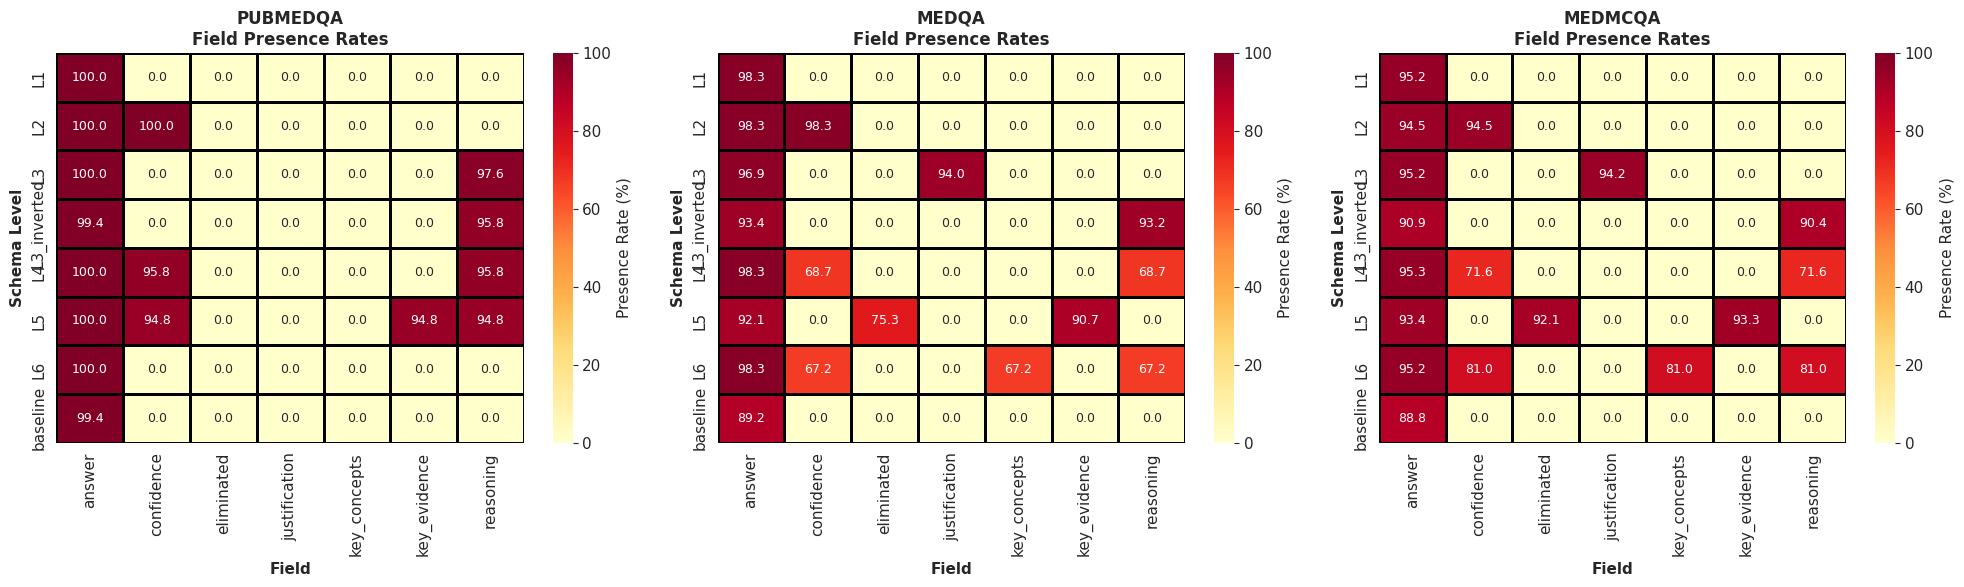

In [15]:
# 2. Field presence heatmap
field_columns = ['has_answer_rate', 'has_confidence_rate', 'has_reasoning_rate', 
                 'has_justification_rate', 'has_eliminated_rate', 'has_key_evidence_rate', 
                 'has_key_concepts_rate']

# Create a combined dataframe for heatmap
heatmap_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in compliance_df[compliance_df['benchmark'] == benchmark]['level'].unique():
        row_data = compliance_df[(compliance_df['benchmark'] == benchmark) & 
                                 (compliance_df['level'] == level)].iloc[0]
        for field in field_columns:
            heatmap_data.append({
                'benchmark': benchmark,
                'level': level,
                'field': field.replace('_rate', '').replace('has_', ''),
                'rate': row_data[field] * 100
            })

heatmap_df = pd.DataFrame(heatmap_data)
pivot_heatmap = heatmap_df.pivot_table(index=['benchmark', 'level'], columns='field', values='rate')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_heatmap = pivot_heatmap.loc[benchmark]
    sns.heatmap(bench_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
                cbar_kws={'label': 'Presence Rate (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9})
    ax.set_xlabel('Field', fontsize=11, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nField Presence Rates', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'field_presence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


##  L3 vs L3_inverted: Schema Order Impact Analysis

**Key Difference**: 
- **L3**: Answer first, then reasoning/justification (standard CoT)
- **L3_inverted**: Reasoning/justification first, then answer (inverted CoT)

**Hypothesis**: Requiring reasoning before the answer (inverted CoT) forces models to think through problems before committing, potentially improving accuracy and reasoning quality.

This section compares these two approaches across all benchmarks.


In [16]:
# L3 vs L3_inverted Comparison Analysis
# Extract comparison data for L3 and L3_inverted across all benchmarks

l3_comparison_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Get L3 and L3_inverted data
    l3_data = compliance_df[(compliance_df['benchmark'] == benchmark) & (compliance_df['level'] == 'L3')]
    l3_inv_data = compliance_df[(compliance_df['benchmark'] == benchmark) & (compliance_df['level'] == 'L3_inverted')]
    
    if len(l3_data) > 0 and len(l3_inv_data) > 0:
        l3_row = l3_data.iloc[0]
        l3_inv_row = l3_inv_data.iloc[0]
        
        # Get accuracy data
        l3_acc = accuracy_df[(accuracy_df['benchmark'] == benchmark) & (accuracy_df['level'] == 'L3')]
        l3_inv_acc = accuracy_df[(accuracy_df['benchmark'] == benchmark) & (accuracy_df['level'] == 'L3_inverted')]
        
        l3_accuracy = l3_acc['accuracy'].values[0] * 100 if len(l3_acc) > 0 else np.nan
        l3_inv_accuracy = l3_inv_acc['accuracy'].values[0] * 100 if len(l3_inv_acc) > 0 else np.nan
        
        # Get parsed samples for reasoning length analysis
        l3_parsed = all_parsed[benchmark].get('L3', [])
        l3_inv_parsed = all_parsed[benchmark].get('L3_inverted', [])
        
        # Calculate reasoning/justification lengths
        l3_reasoning_lengths = []
        l3_inv_reasoning_lengths = []
        
        for p in l3_parsed:
            if benchmark == 'pubmedqa':
                reasoning = p.get('reasoning', '')
            else:  # medqa, medmcqa
                reasoning = p.get('justification', '')
            if reasoning:
                l3_reasoning_lengths.append(len(reasoning))
        
        for p in l3_inv_parsed:
            reasoning = p.get('reasoning', '')
            if reasoning:
                l3_inv_reasoning_lengths.append(len(reasoning))
        
        l3_comparison_data.append({
            'benchmark': benchmark,
            'l3_accuracy': l3_accuracy,
            'l3_inv_accuracy': l3_inv_accuracy,
            'accuracy_diff': l3_inv_accuracy - l3_accuracy,
            'l3_json_valid': l3_row['json_valid_rate'] * 100,
            'l3_inv_json_valid': l3_inv_row['json_valid_rate'] * 100,
            'json_valid_diff': (l3_inv_row['json_valid_rate'] - l3_row['json_valid_rate']) * 100,
            'l3_schema_compliant': l3_row['schema_compliant_rate'] * 100,
            'l3_inv_schema_compliant': l3_inv_row['schema_compliant_rate'] * 100,
            'schema_compliant_diff': (l3_inv_row['schema_compliant_rate'] - l3_row['schema_compliant_rate']) * 100,
            'l3_has_reasoning': l3_row['has_reasoning_rate'] * 100 if 'has_reasoning_rate' in l3_row else l3_row.get('has_justification_rate', 0) * 100,
            'l3_inv_has_reasoning': l3_inv_row['has_reasoning_rate'] * 100,
            'l3_avg_reasoning_length': np.mean(l3_reasoning_lengths) if l3_reasoning_lengths else 0,
            'l3_inv_avg_reasoning_length': np.mean(l3_inv_reasoning_lengths) if l3_inv_reasoning_lengths else 0,
            'reasoning_length_diff': (np.mean(l3_inv_reasoning_lengths) if l3_inv_reasoning_lengths else 0) - 
                                     (np.mean(l3_reasoning_lengths) if l3_reasoning_lengths else 0),
        })

l3_comparison_df = pd.DataFrame(l3_comparison_data)
print("L3 vs L3_inverted Comparison Data:")
print(l3_comparison_df[['benchmark', 'l3_accuracy', 'l3_inv_accuracy', 'accuracy_diff', 
                        'l3_json_valid', 'l3_inv_json_valid', 'l3_schema_compliant', 'l3_inv_schema_compliant']].to_string(index=False))


L3 vs L3_inverted Comparison Data:
benchmark  l3_accuracy  l3_inv_accuracy  accuracy_diff  l3_json_valid  l3_inv_json_valid  l3_schema_compliant  l3_inv_schema_compliant
 pubmedqa    77.200000        76.400000      -0.800000      97.600000          95.800000            97.600000                95.800000
    medqa    61.272584        59.387274      -1.885310      94.029851          93.244305            94.029851                93.244305
  medmcqa    54.506335        51.757112      -2.749223      94.166866          90.437485            94.166866                90.437485


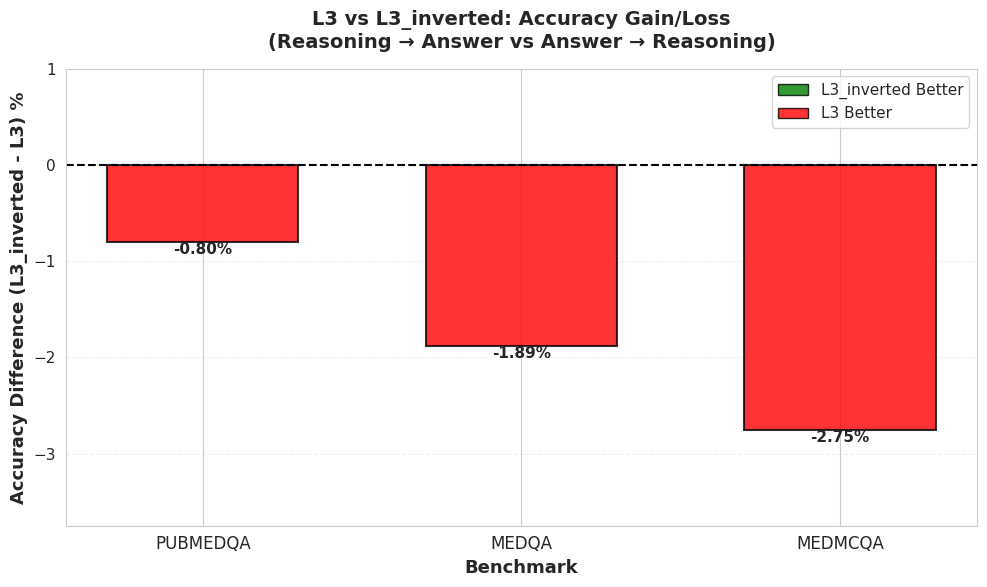


L3 vs L3_inverted: Summary Statistics

Metric                         L3              L3_inverted     Difference     
--------------------------------------------------------------------------------

PUBMEDQA:
  Accuracy (%)              77.20           76.40           -0.80%
  JSON Valid (%)            97.60           95.80           -1.80%
  Schema Compliant (%)      97.60           95.80           -1.80%
  Avg Reasoning Length      198             179             -19 chars

MEDQA:
  Accuracy (%)              61.27           59.39           -1.89%
  JSON Valid (%)            94.03           93.24           -0.79%
  Schema Compliant (%)      94.03           93.24           -0.79%
  Avg Reasoning Length      200             200             +0 chars

MEDMCQA:
  Accuracy (%)              54.51           51.76           -2.75%
  JSON Valid (%)            94.17           90.44           -3.73%
  Schema Compliant (%)      94.17           90.44           -3.73%
  Avg Reasoning Length      1

In [17]:
# Create L3 vs L3_inverted accuracy gain/loss visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(l3_comparison_df))
colors = ['green' if d > 0 else 'red' for d in l3_comparison_df['accuracy_diff']]
bars = ax.bar(x, l3_comparison_df['accuracy_diff'], 
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add zero reference line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Add value labels on bars
for bar, diff in zip(bars, l3_comparison_df['accuracy_diff']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{diff:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Difference (L3_inverted - L3) %', fontsize=13, fontweight='bold')
ax.set_title('L3 vs L3_inverted: Accuracy Gain/Loss\n(Reasoning → Answer vs Answer → Reasoning)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in l3_comparison_df['benchmark']], fontsize=12)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim(bottom=min(l3_comparison_df['accuracy_diff'].min() - 1, -1) if len(l3_comparison_df) > 0 else -1,
            top=max(l3_comparison_df['accuracy_diff'].max() + 1, 1) if len(l3_comparison_df) > 0 else 1)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.8, edgecolor='black', label='L3_inverted Better'),
    Patch(facecolor='red', alpha=0.8, edgecolor='black', label='L3 Better')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_vs_l3_inverted_accuracy_gain_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("L3 vs L3_inverted: Summary Statistics")
print("="*80)
print(f"\n{'Metric':<30} {'L3':<15} {'L3_inverted':<15} {'Difference':<15}")
print("-"*80)
for _, row in l3_comparison_df.iterrows():
    benchmark = row['benchmark'].upper()
    print(f"\n{benchmark}:")
    print(f"  Accuracy (%)              {row['l3_accuracy']:<15.2f} {row['l3_inv_accuracy']:<15.2f} {row['accuracy_diff']:+.2f}%")
    print(f"  JSON Valid (%)            {row['l3_json_valid']:<15.2f} {row['l3_inv_json_valid']:<15.2f} {row['json_valid_diff']:+.2f}%")
    print(f"  Schema Compliant (%)      {row['l3_schema_compliant']:<15.2f} {row['l3_inv_schema_compliant']:<15.2f} {row['schema_compliant_diff']:+.2f}%")
    print(f"  Avg Reasoning Length      {row['l3_avg_reasoning_length']:<15.0f} {row['l3_inv_avg_reasoning_length']:<15.0f} {row['reasoning_length_diff']:+.0f} chars")

print("\n" + "="*80)
print("Key Findings:")
print("="*80)
for _, row in l3_comparison_df.iterrows():
    benchmark = row['benchmark'].upper()
    acc_diff = row['accuracy_diff']
    if acc_diff > 0:
        print(f"✓ {benchmark}: L3_inverted improves accuracy by {acc_diff:.2f}%")
    elif acc_diff < 0:
        print(f"✗ {benchmark}: L3_inverted decreases accuracy by {abs(acc_diff):.2f}%")
    else:
        print(f"= {benchmark}: No accuracy difference")
print("="*80)


## 4.3 Confidence and Calibration Behavior

This section analyzes model calibration: how well confidence scores correlate with actual accuracy, and whether structured constraints affect calibration.


In [18]:
# Compute Expected Calibration Error (ECE)
def compute_ece(confidences, correct, n_bins=10):
    """Compute Expected Calibration Error."""
    if len(confidences) == 0 or len(correct) == 0:
        return np.nan
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = correct[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

# Extract confidence and correctness data
calibration_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        
        # Filter to samples with confidence
        conf_samples = [p for p in parsed if p['has_confidence'] and p['confidence'] is not None]
        
        if len(conf_samples) == 0:
            continue
        
        confidences = np.array([p['confidence'] for p in conf_samples])
        correct = np.array([p['exact_match'] for p in conf_samples])
        
        ece = compute_ece(confidences, correct)
        mean_confidence = np.mean(confidences)
        mean_accuracy = np.mean(correct)
        correlation = np.corrcoef(confidences, correct)[0, 1] if len(confidences) > 1 else np.nan
        
        calibration_data.append({
            'benchmark': benchmark,
            'level': level,
            'n_with_confidence': len(conf_samples),
            'ece': ece,
            'mean_confidence': mean_confidence,
            'mean_accuracy': mean_accuracy,
            'correlation': correlation,
            'confidences': confidences,
            'correct': correct,
        })

calibration_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['confidences', 'correct']} 
                                for d in calibration_data])
print("Calibration metrics computed")
print(calibration_df.groupby('benchmark')[['ece', 'correlation']].mean())


Calibration metrics computed
                ece  correlation
benchmark                       
medmcqa    0.303002     0.031356
medqa      0.286796     0.009947
pubmedqa   0.196713     0.088443


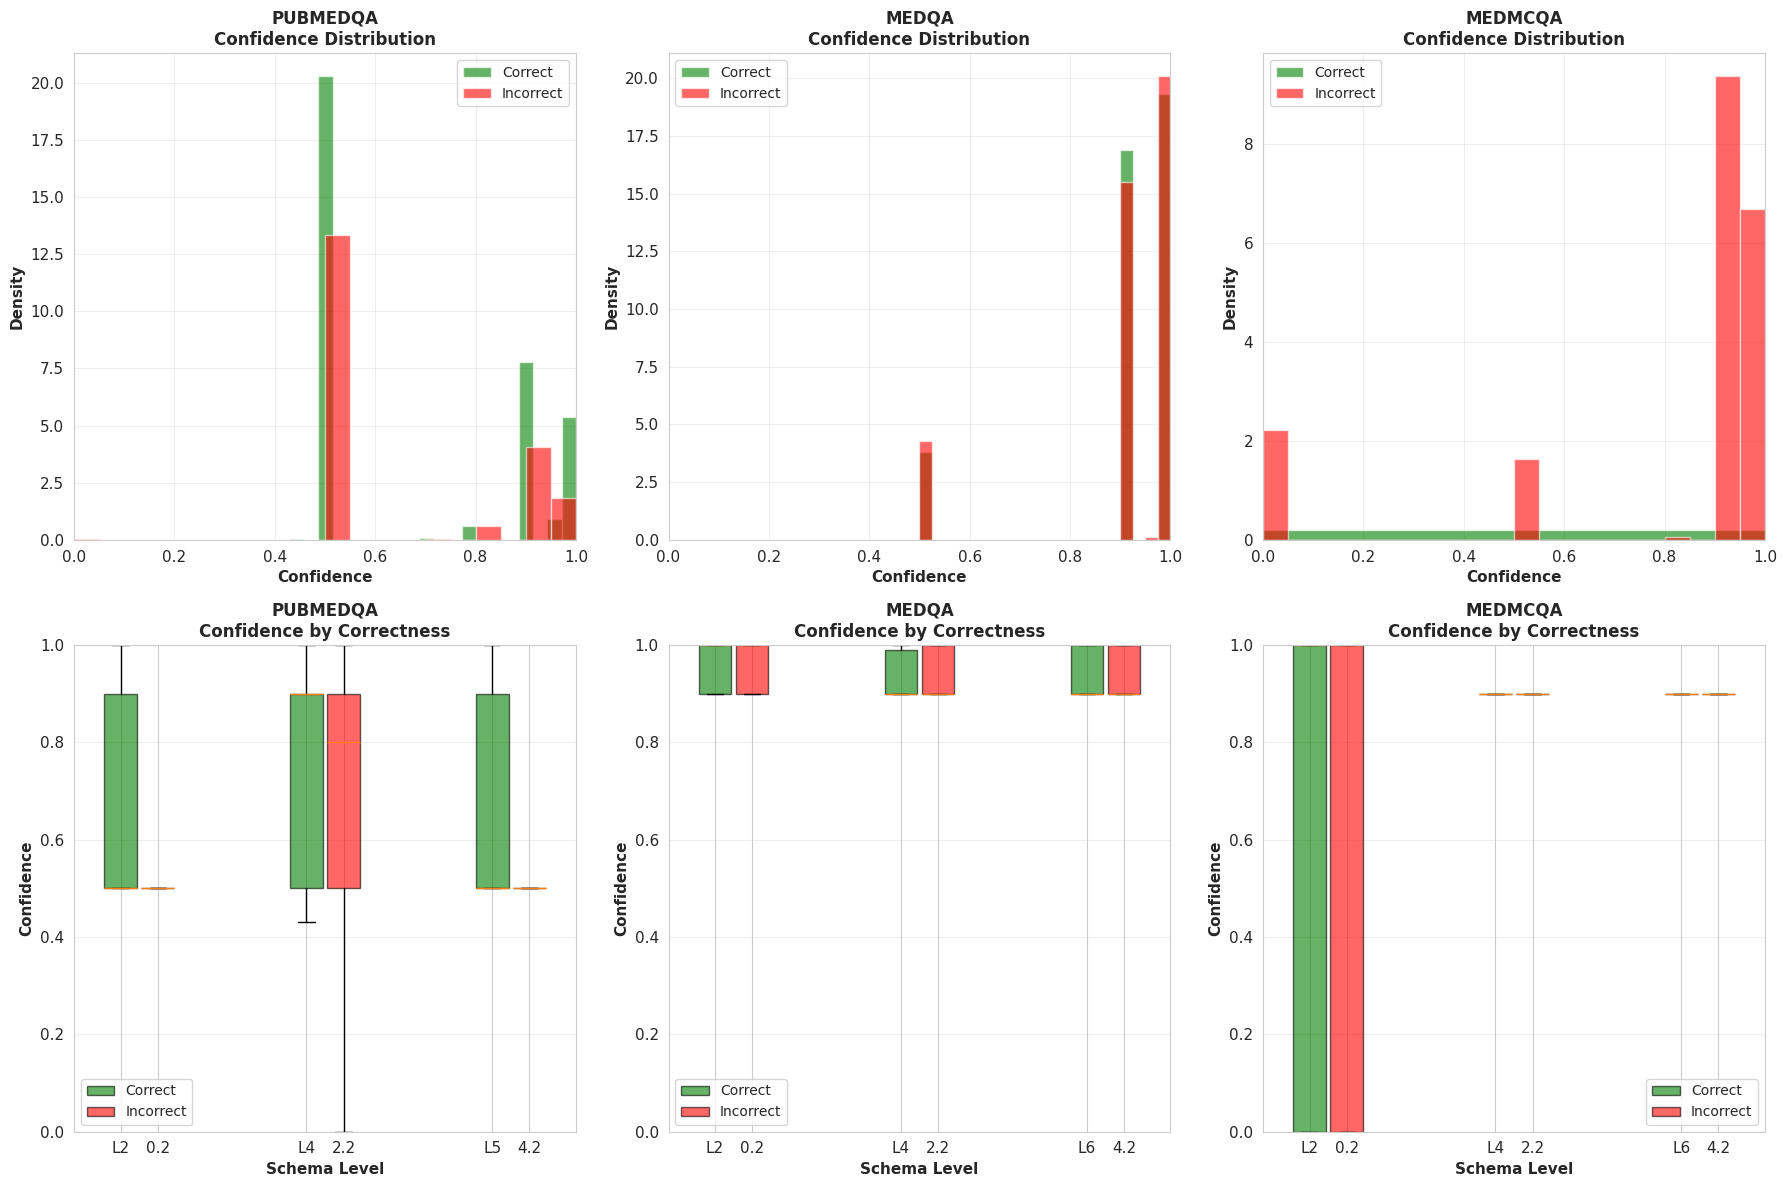

In [19]:
# 1. Confidence distributions (correct vs incorrect answers)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    # Get all confidence data for this benchmark
    all_conf_correct = []
    all_conf_incorrect = []
    
    for calib_item in calibration_data:
        if calib_item['benchmark'] == benchmark:
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            all_conf_correct.extend(confidences[correct == 1])
            all_conf_incorrect.extend(confidences[correct == 0])
    
    if len(all_conf_correct) > 0 or len(all_conf_incorrect) > 0:
        ax = axes[0, idx]
        ax.hist(all_conf_correct, bins=20, alpha=0.6, label='Correct', color='green', density=True)
        ax.hist(all_conf_incorrect, bins=20, alpha=0.6, label='Incorrect', color='red', density=True)
        ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
        ax.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax.set_title(f'{benchmark.upper()}\nConfidence Distribution', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
    
    # Confidence by correctness (box plot)
    ax = axes[1, idx]
    conf_by_level = []
    labels = []
    
    for level in sorted(set([c['level'] for c in calibration_data if c['benchmark'] == benchmark])):
        calib_item = next((c for c in calibration_data if c['benchmark'] == benchmark and c['level'] == level), None)
        if calib_item:
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            conf_by_level.append([confidences[correct == 1], confidences[correct == 0]])
            labels.append(level)
    
    if conf_by_level:
        correct_confs = [c[0] for c in conf_by_level if len(c[0]) > 0]
        incorrect_confs = [c[1] for c in conf_by_level if len(c[1]) > 0]
        
        positions_correct = np.arange(len(correct_confs)) * 2 - 0.2
        positions_incorrect = np.arange(len(incorrect_confs)) * 2 + 0.2
        
        bp1 = ax.boxplot(correct_confs, positions=positions_correct, widths=0.35, 
                         patch_artist=True, labels=labels, showfliers=False)
        bp2 = ax.boxplot(incorrect_confs, positions=positions_incorrect, widths=0.35,
                         patch_artist=True, showfliers=False)
        
        for patch in bp1['boxes']:
            patch.set_facecolor('green')
            patch.set_alpha(0.6)
        for patch in bp2['boxes']:
            patch.set_facecolor('red')
            patch.set_alpha(0.6)
        
        ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
        ax.set_ylabel('Confidence', fontsize=11, fontweight='bold')
        ax.set_title(f'{benchmark.upper()}\nConfidence by Correctness', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 1)
        ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Correct', 'Incorrect'], fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confidence_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


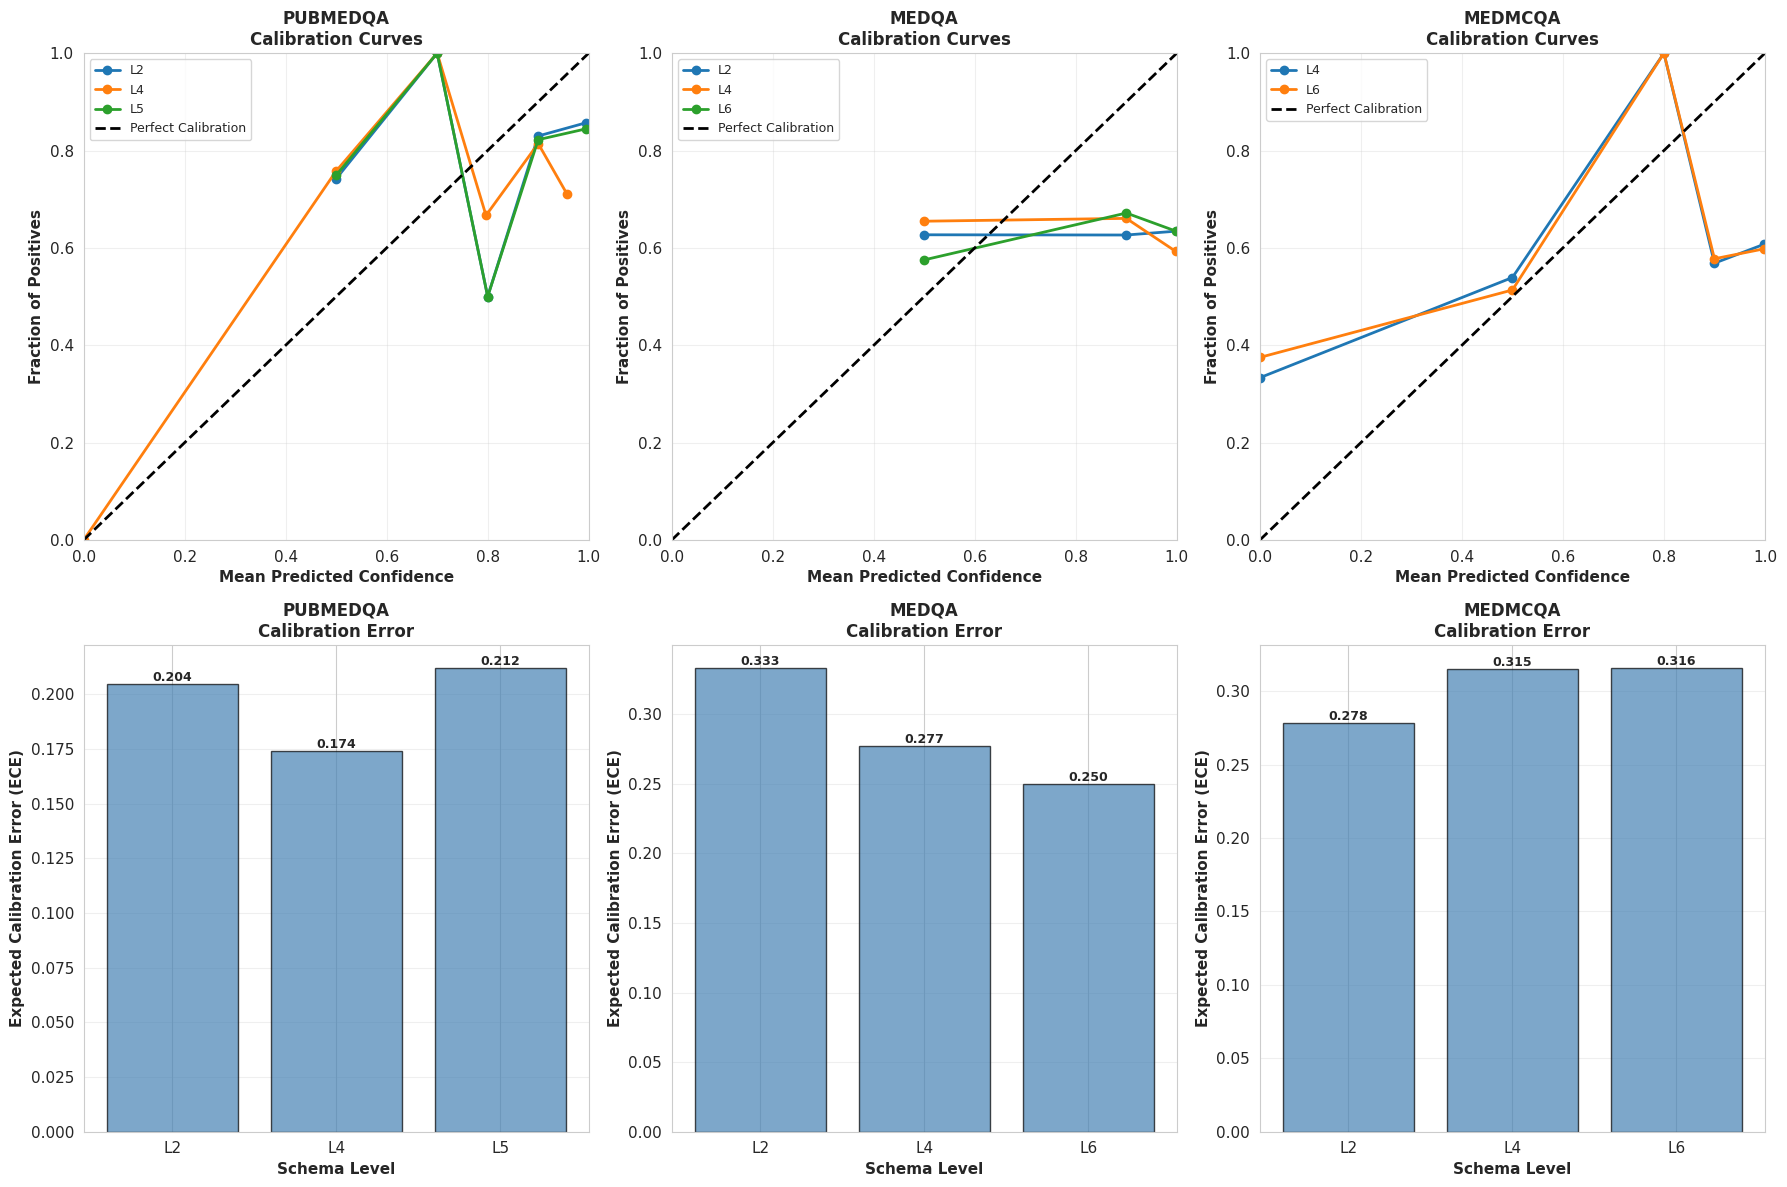

In [20]:
# 2. Calibration curves for each benchmark/level
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax1 = axes[0, idx]
    ax2 = axes[1, idx]
    
    for calib_item in calibration_data:
        if calib_item['benchmark'] == benchmark:
            level = calib_item['level']
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            
            if len(confidences) > 10:  # Need enough samples
                try:
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        correct, confidences, n_bins=10, strategy='uniform'
                    )
                    ax1.plot(mean_predicted_value, fraction_of_positives, marker='o', 
                            label=level, linewidth=2, markersize=6)
                except:
                    pass
    
    # Perfect calibration line
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.set_xlabel('Mean Predicted Confidence', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
    ax1.set_title(f'{benchmark.upper()}\nCalibration Curves', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # ECE comparison
    bench_calib = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_calib = bench_calib.sort_values('level')
    
    if len(bench_calib) > 0:
        ax2.bar(bench_calib['level'], bench_calib['ece'], alpha=0.7, color='steelblue', edgecolor='black')
        ax2.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Expected Calibration Error (ECE)', fontsize=11, fontweight='bold')
        ax2.set_title(f'{benchmark.upper()}\nCalibration Error', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, (level, ece) in enumerate(zip(bench_calib['level'], bench_calib['ece'])):
            ax2.text(i, ece, f'{ece:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()


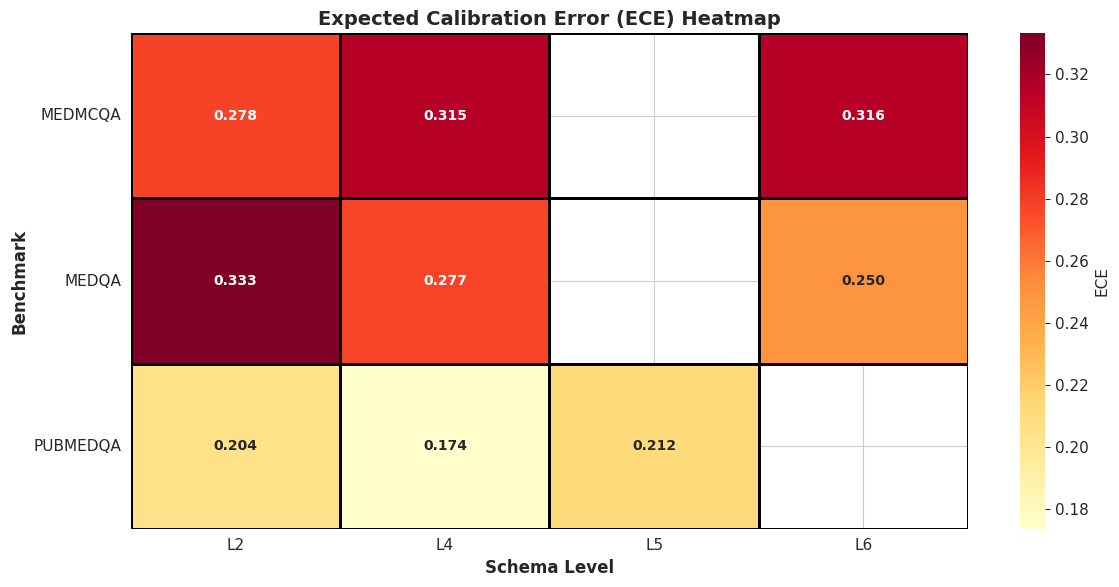

In [21]:
# 3. ECE comparison across levels (heatmap)
ece_pivot = calibration_df.pivot(index='benchmark', columns='level', values='ece')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ece_pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'ECE'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Expected Calibration Error (ECE) Heatmap', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in ece_pivot.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ece_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.4 Decision Distribution Shifts

This section analyzes whether structured constraints change answer patterns, including distribution shifts and answer transition patterns.


In [22]:
# Compute answer distributions and shift metrics
from scipy.stats import entropy

def kl_divergence(p, q):
    """Compute KL divergence between two distributions."""
    p = np.array(p)
    q = np.array(q)
    # Avoid division by zero
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    return np.sum(p * np.log(p / q))

distribution_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Determine valid answers
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
    else:
        valid_answers = ['A', 'B', 'C', 'D']
    
    # Get reference distribution (baseline or L1)
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    if reference_level not in all_parsed[benchmark]:
        continue
    
    ref_parsed = all_parsed[benchmark][reference_level]
    ref_answers = [p['answer'] for p in ref_parsed if p['answer'] != '[invalid]']
    ref_counts = Counter(ref_answers)
    ref_dist = np.array([ref_counts.get(a, 0) for a in valid_answers])
    ref_dist = ref_dist / ref_dist.sum() if ref_dist.sum() > 0 else ref_dist
    
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        answers = [p['answer'] for p in parsed if p['answer'] != '[invalid]']
        counts = Counter(answers)
        dist = np.array([counts.get(a, 0) for a in valid_answers])
        dist = dist / dist.sum() if dist.sum() > 0 else dist
        
        # Compute KL divergence from reference
        kl_div = kl_divergence(dist, ref_dist) if dist.sum() > 0 and ref_dist.sum() > 0 else np.nan
        
        # Compute chi-square test
        if dist.sum() > 0 and ref_dist.sum() > 0:
            observed = dist * len(answers) if len(answers) > 0 else dist
            expected = ref_dist * len(answers) if len(answers) > 0 else ref_dist
            # Avoid zero expected values
            observed = observed + 1e-10
            expected = expected + 1e-10
            chi2_stat = np.sum((observed - expected)**2 / expected)
        else:
            chi2_stat = np.nan
        
        distribution_data.append({
            'benchmark': benchmark,
            'level': level,
            'distribution': dict(zip(valid_answers, dist)),
            'counts': dict(zip(valid_answers, [counts.get(a, 0) for a in valid_answers])),
            'kl_divergence': kl_div,
            'chi2_statistic': chi2_stat,
            'valid_answers': valid_answers,
        })

distribution_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['distribution', 'counts', 'valid_answers']} 
                                for d in distribution_data])
print("Distribution metrics computed")


Distribution metrics computed


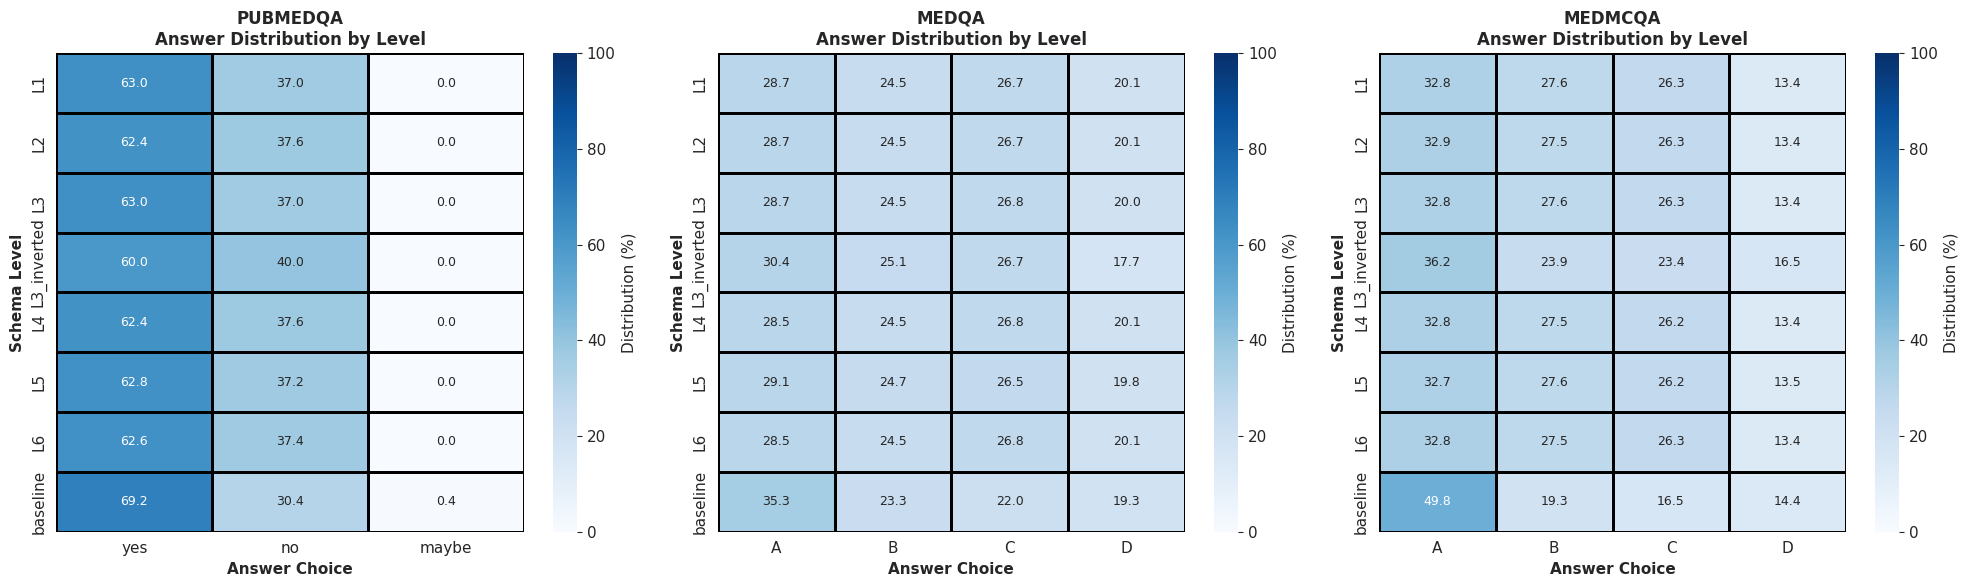

In [23]:
# 1. Answer distribution heatmaps (level × answer choice)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_dist = [d for d in distribution_data if d['benchmark'] == benchmark]
    
    if not bench_dist:
        continue
    
    valid_answers = bench_dist[0]['valid_answers']
    levels = sorted(set([d['level'] for d in bench_dist]))
    
    # Create matrix
    dist_matrix = []
    for level in levels:
        dist_item = next((d for d in bench_dist if d['level'] == level), None)
        if dist_item:
            dist = [dist_item['distribution'].get(a, 0) for a in valid_answers]
            dist_matrix.append(dist)
        else:
            dist_matrix.append([0] * len(valid_answers))
    
    dist_matrix = np.array(dist_matrix) * 100  # Convert to percentage
    
    sns.heatmap(dist_matrix, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=levels,
                cbar_kws={'label': 'Distribution (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9})
    ax.set_xlabel('Answer Choice', fontsize=11, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Distribution by Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_distribution_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


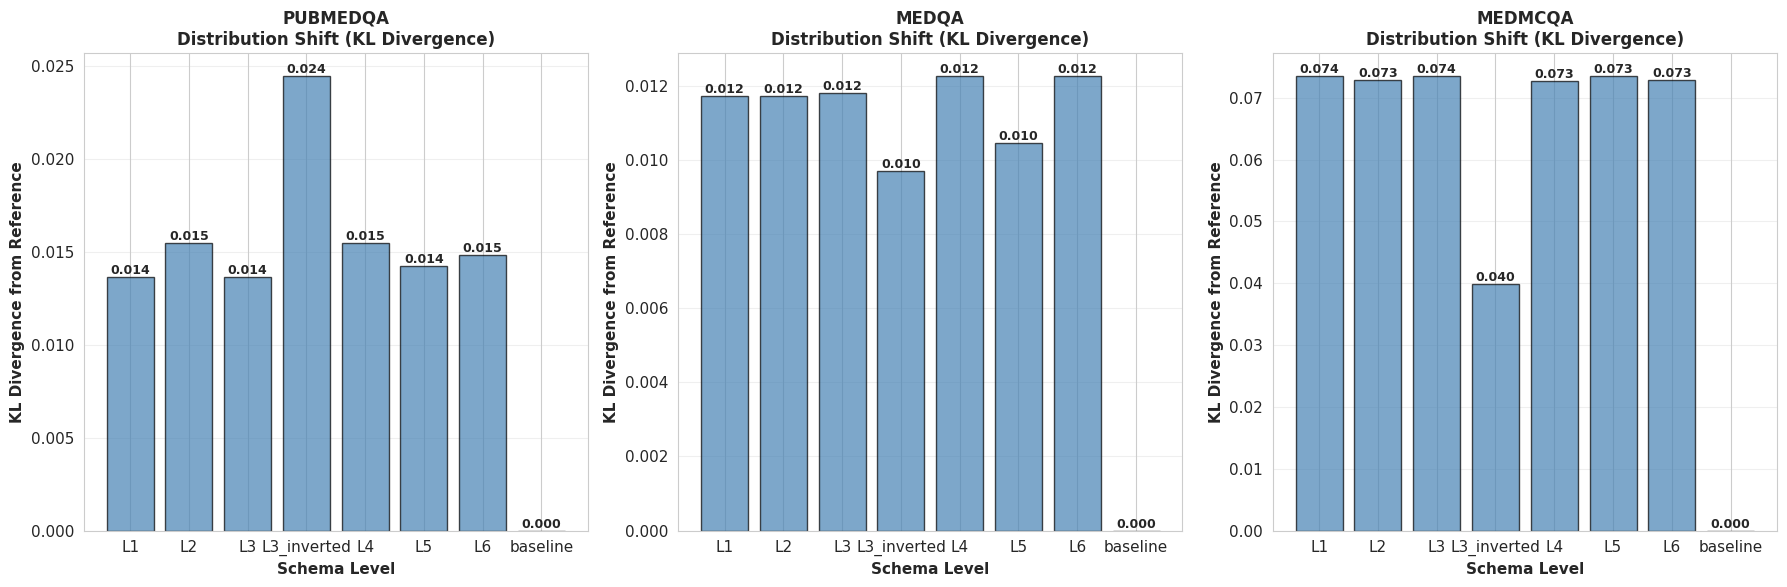

In [24]:
# 2. Distribution shift visualization (KL divergence)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = distribution_df[distribution_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    kl_divs = bench_data['kl_divergence'].values
    
    bars = ax.bar(levels, kl_divs, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('KL Divergence from Reference', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nDistribution Shift (KL Divergence)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, kl_div in zip(bars, kl_divs):
        if not np.isnan(kl_div):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{kl_div:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'distribution_shift_kl.png', dpi=300, bbox_inches='tight')
plt.show()


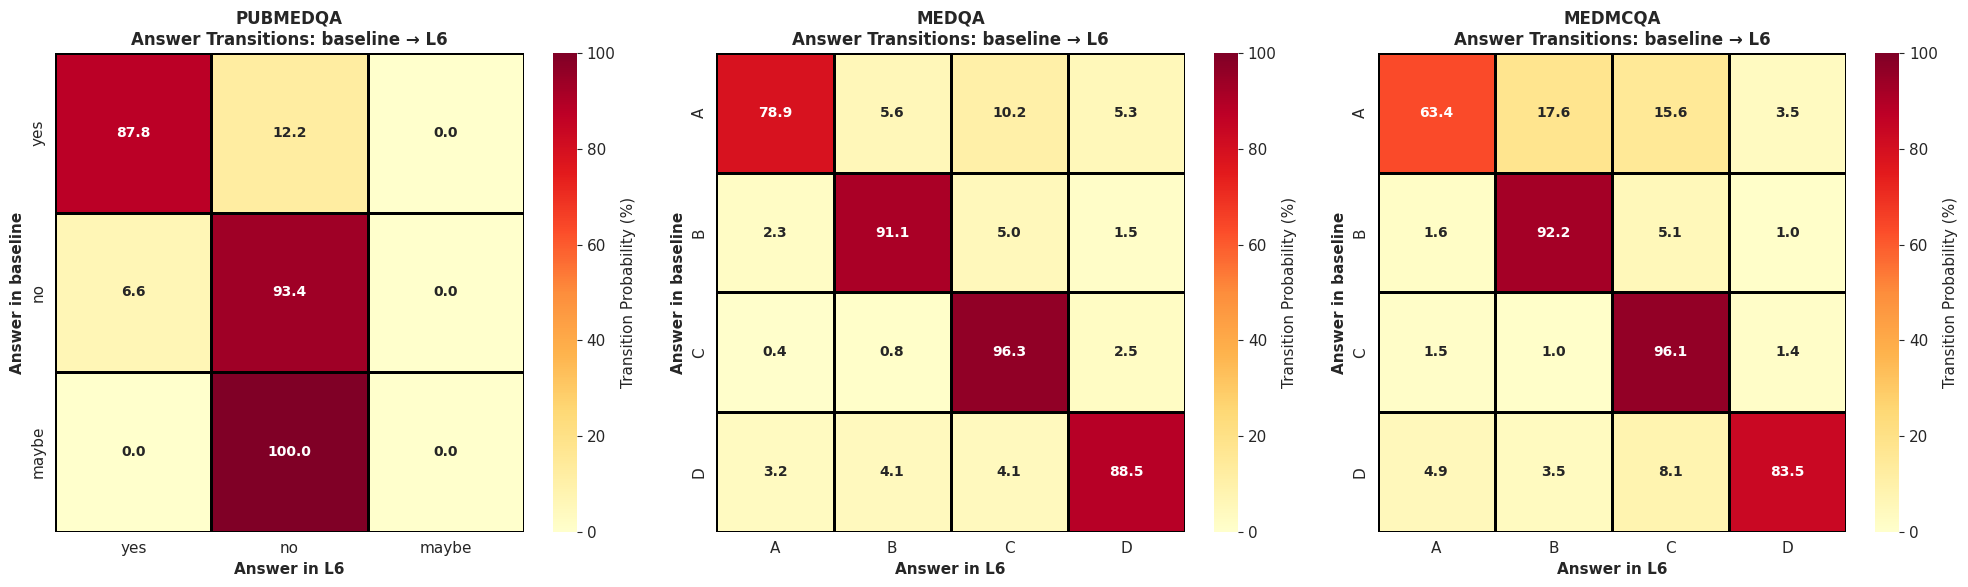

In [25]:
# 3. Answer transition matrices between levels
def create_transition_matrix(benchmark, from_level, to_level):
    """Create transition matrix showing answer changes between levels."""
    from_parsed = all_parsed[benchmark][from_level]
    to_parsed = all_parsed[benchmark][to_level]
    
    # Match by doc_id
    from_dict = {p['doc_id']: p['answer'] for p in from_parsed}
    to_dict = {p['doc_id']: p['answer'] for p in to_parsed}
    
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
    else:
        valid_answers = ['A', 'B', 'C', 'D']
    
    # Create transition matrix
    transition = np.zeros((len(valid_answers), len(valid_answers)))
    
    for doc_id in from_dict.keys():
        if doc_id in to_dict:
            from_ans = from_dict[doc_id]
            to_ans = to_dict[doc_id]
            if from_ans in valid_answers and to_ans in valid_answers:
                i = valid_answers.index(from_ans)
                j = valid_answers.index(to_ans)
                transition[i, j] += 1
    
    # Normalize by row
    row_sums = transition.sum(axis=1, keepdims=True)
    transition = transition / (row_sums + 1e-10) * 100
    
    return transition, valid_answers

# Create transition matrices for each benchmark (baseline/L1 to L6)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    from_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    to_level = 'L6'
    
    if from_level not in all_parsed[benchmark] or to_level not in all_parsed[benchmark]:
        continue
    
    transition, valid_answers = create_transition_matrix(benchmark, from_level, to_level)
    
    sns.heatmap(transition, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=valid_answers,
                cbar_kws={'label': 'Transition Probability (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_xlabel(f'Answer in {to_level}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Answer in {from_level}', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Transitions: {from_level} → {to_level}', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_transition_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


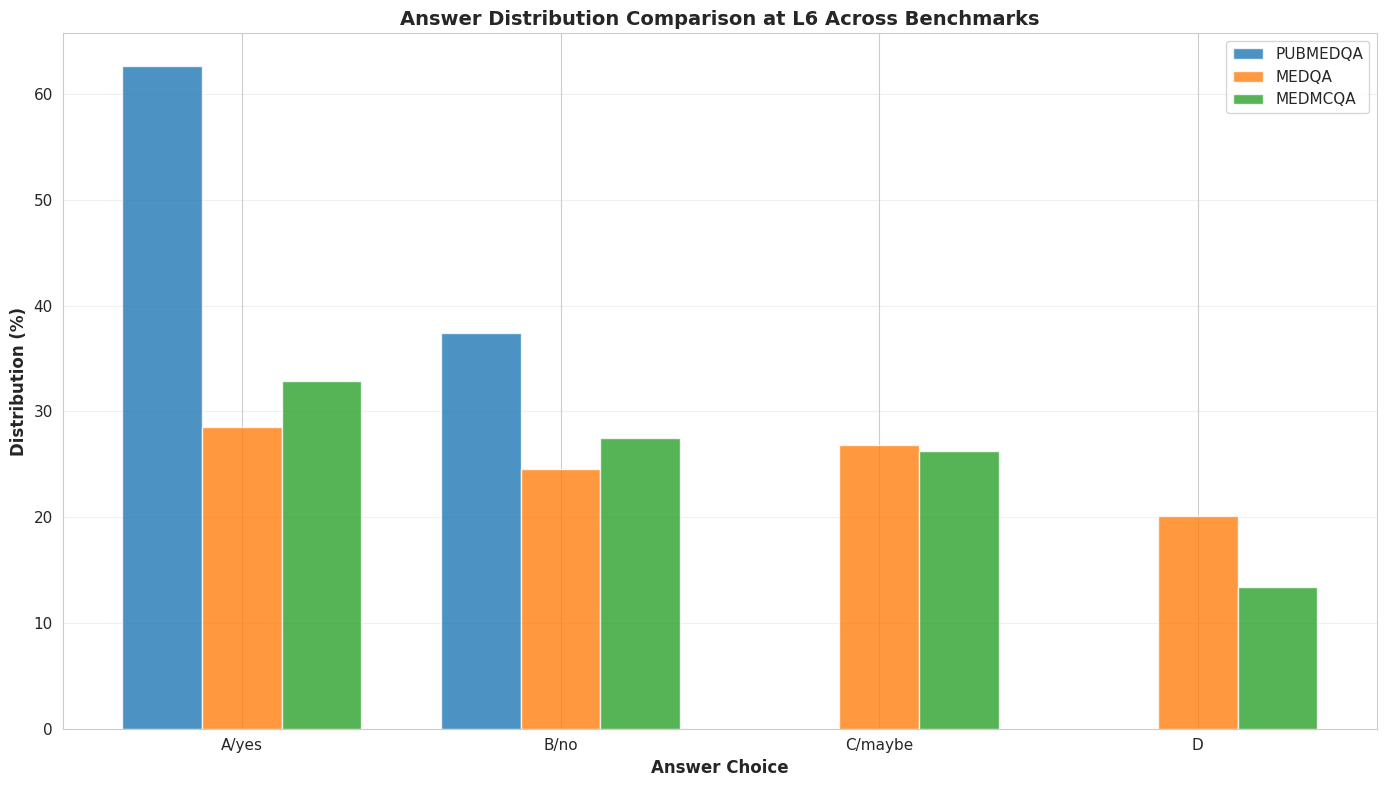

In [26]:
# 4. Cross-benchmark distribution comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Compare distributions at L6 across benchmarks
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    if 'L6' not in all_parsed[benchmark]:
        continue
    
    dist_item = next((d for d in distribution_data if d['benchmark'] == benchmark and d['level'] == 'L6'), None)
    if dist_item:
        valid_answers = dist_item['valid_answers']
        dist = [dist_item['distribution'].get(a, 0) * 100 for a in valid_answers]
        
        x = np.arange(len(valid_answers))
        width = 0.25
        offset = {'pubmedqa': -width, 'medqa': 0, 'medmcqa': width}[benchmark]
        
        ax.bar(x + offset, dist, width, label=benchmark.upper(), alpha=0.8)

ax.set_xlabel('Answer Choice', fontsize=12, fontweight='bold')
ax.set_ylabel('Distribution (%)', fontsize=12, fontweight='bold')
ax.set_title('Answer Distribution Comparison at L6 Across Benchmarks', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# Use common labels (A/B/C/D for MCQ, yes/no/maybe for PubMedQA)
ax.set_xticklabels(['A/yes', 'B/no', 'C/maybe', 'D'] if len(x) == 4 else ['yes', 'no', 'maybe'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cross_benchmark_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.5 Comprehensive Answer Distribution Shift Analysis

This section provides a comprehensive multi-metric analysis of answer distribution shifts across all schema levels and benchmarks, using multiple statistical approaches to identify patterns and relationships between distribution changes and performance metrics.


In [27]:
# Comprehensive Distribution Shift Analysis
# Step 1: Extract and normalize answer distributions for all benchmarks and levels

from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon

def compute_kl_divergence(p, q):
    """Compute KL divergence D(P||Q)."""
    p = np.array(p)
    q = np.array(q)
    # Avoid division by zero
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    return np.sum(p * np.log(p / q))

def compute_jensen_shannon(p, q):
    """Compute Jensen-Shannon divergence (symmetric)."""
    p = np.array(p)
    q = np.array(q)
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    return jensenshannon(p, q)

def compute_total_variation_distance(p, q):
    """Compute Total Variation Distance (L1 norm)."""
    p = np.array(p)
    q = np.array(q)
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    return 0.5 * np.sum(np.abs(p - q))

def compute_wasserstein_distance(p, q):
    """Compute Wasserstein distance (Earth Mover's Distance)."""
    p = np.array(p)
    q = np.array(q)
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    # For discrete distributions, use cumulative distribution
    return wasserstein_distance(np.arange(len(p)), np.arange(len(q)), p, q)

def compute_chi2_statistic(observed, expected):
    """Compute chi-square statistic."""
    observed = np.array(observed)
    expected = np.array(expected)
    # Avoid division by zero
    observed = observed + 1e-10
    expected = expected + 1e-10
    return np.sum((observed - expected)**2 / expected)

# Extract comprehensive distribution data
comprehensive_distribution_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Determine valid answers
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
    else:
        valid_answers = ['A', 'B', 'C', 'D']
    
    # Get reference distribution (baseline or L1)
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    if reference_level not in all_parsed[benchmark]:
        continue
    
    ref_parsed = all_parsed[benchmark][reference_level]
    ref_answers = [p['answer'] for p in ref_parsed if p['answer'] != '[invalid]']
    ref_counts = Counter(ref_answers)
    ref_dist = np.array([ref_counts.get(a, 0) for a in valid_answers], dtype=float)
    ref_total = ref_dist.sum()
    ref_dist = ref_dist / ref_total if ref_total > 0 else ref_dist
    
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        answers = [p['answer'] for p in parsed if p['answer'] != '[invalid]']
        counts = Counter(answers)
        dist = np.array([counts.get(a, 0) for a in valid_answers], dtype=float)
        total = dist.sum()
        dist = dist / total if total > 0 else dist
        
        # Compute all distance metrics from reference
        kl_div = compute_kl_divergence(dist, ref_dist) if total > 0 and ref_total > 0 else np.nan
        js_div = compute_jensen_shannon(dist, ref_dist) if total > 0 and ref_total > 0 else np.nan
        tv_dist = compute_total_variation_distance(dist, ref_dist) if total > 0 and ref_total > 0 else np.nan
        wass_dist = compute_wasserstein_distance(dist, ref_dist) if total > 0 and ref_total > 0 else np.nan
        
        # Chi-square test
        if total > 0 and ref_total > 0:
            observed = dist * len(answers) if len(answers) > 0 else dist
            expected = ref_dist * len(answers) if len(answers) > 0 else ref_dist
            chi2_stat = compute_chi2_statistic(observed, expected)
        else:
            chi2_stat = np.nan
        
        # Store distribution as percentages
        dist_percentages = {a: dist[i] * 100 for i, a in enumerate(valid_answers)}
        counts_dict = {a: counts.get(a, 0) for a in valid_answers}
        
        comprehensive_distribution_data.append({
            'benchmark': benchmark,
            'level': level,
            'distribution': dist_percentages,
            'counts': counts_dict,
            'kl_divergence': kl_div,
            'jensen_shannon': js_div,
            'total_variation': tv_dist,
            'wasserstein': wass_dist,
            'chi2_statistic': chi2_stat,
            'valid_answers': valid_answers,
            'n_samples': len(answers),
        })

comprehensive_dist_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['distribution', 'counts', 'valid_answers']} 
                                      for d in comprehensive_distribution_data])

print("Comprehensive distribution metrics computed:")
print(f"  Total (benchmark, level) combinations: {len(comprehensive_dist_df)}")
print(f"  Metrics: KL Divergence, Jensen-Shannon, Total Variation, Wasserstein, Chi-square")


Comprehensive distribution metrics computed:
  Total (benchmark, level) combinations: 24
  Metrics: KL Divergence, Jensen-Shannon, Total Variation, Wasserstein, Chi-square


In [28]:
# Step 2: Analyze shift patterns - direction and magnitude
# Identify which answer choices increase/decrease across levels

shift_patterns = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Get reference distribution
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    ref_item = next((d for d in comprehensive_distribution_data 
                     if d['benchmark'] == benchmark and d['level'] == reference_level), None)
    if not ref_item:
        continue
    
    ref_dist = ref_item['distribution']
    valid_answers = ref_item['valid_answers']
    
    for level in all_parsed[benchmark].keys():
        if level == reference_level:
            continue
        
        level_item = next((d for d in comprehensive_distribution_data 
                          if d['benchmark'] == benchmark and d['level'] == level), None)
        if not level_item:
            continue
        
        level_dist = level_item['distribution']
        
        # Calculate shift for each answer choice
        shifts = {}
        for ans in valid_answers:
            ref_pct = ref_dist.get(ans, 0)
            level_pct = level_dist.get(ans, 0)
            shift = level_pct - ref_pct
            shifts[ans] = shift
        
        # Identify largest increases and decreases
        sorted_shifts = sorted(shifts.items(), key=lambda x: x[1], reverse=True)
        max_increase = sorted_shifts[0] if sorted_shifts else (None, 0)
        max_decrease = sorted_shifts[-1] if sorted_shifts else (None, 0)
        
        # Calculate overall shift magnitude (sum of absolute changes)
        shift_magnitude = sum(abs(s) for s in shifts.values())
        
        shift_patterns.append({
            'benchmark': benchmark,
            'level': level,
            'shifts': shifts,
            'max_increase_choice': max_increase[0],
            'max_increase_value': max_increase[1],
            'max_decrease_choice': max_decrease[0],
            'max_decrease_value': max_decrease[1],
            'shift_magnitude': shift_magnitude,
        })

shift_patterns_df = pd.DataFrame(shift_patterns)
print("Shift patterns analyzed:")
print(f"  Total level transitions: {len(shift_patterns_df)}")


Shift patterns analyzed:
  Total level transitions: 21


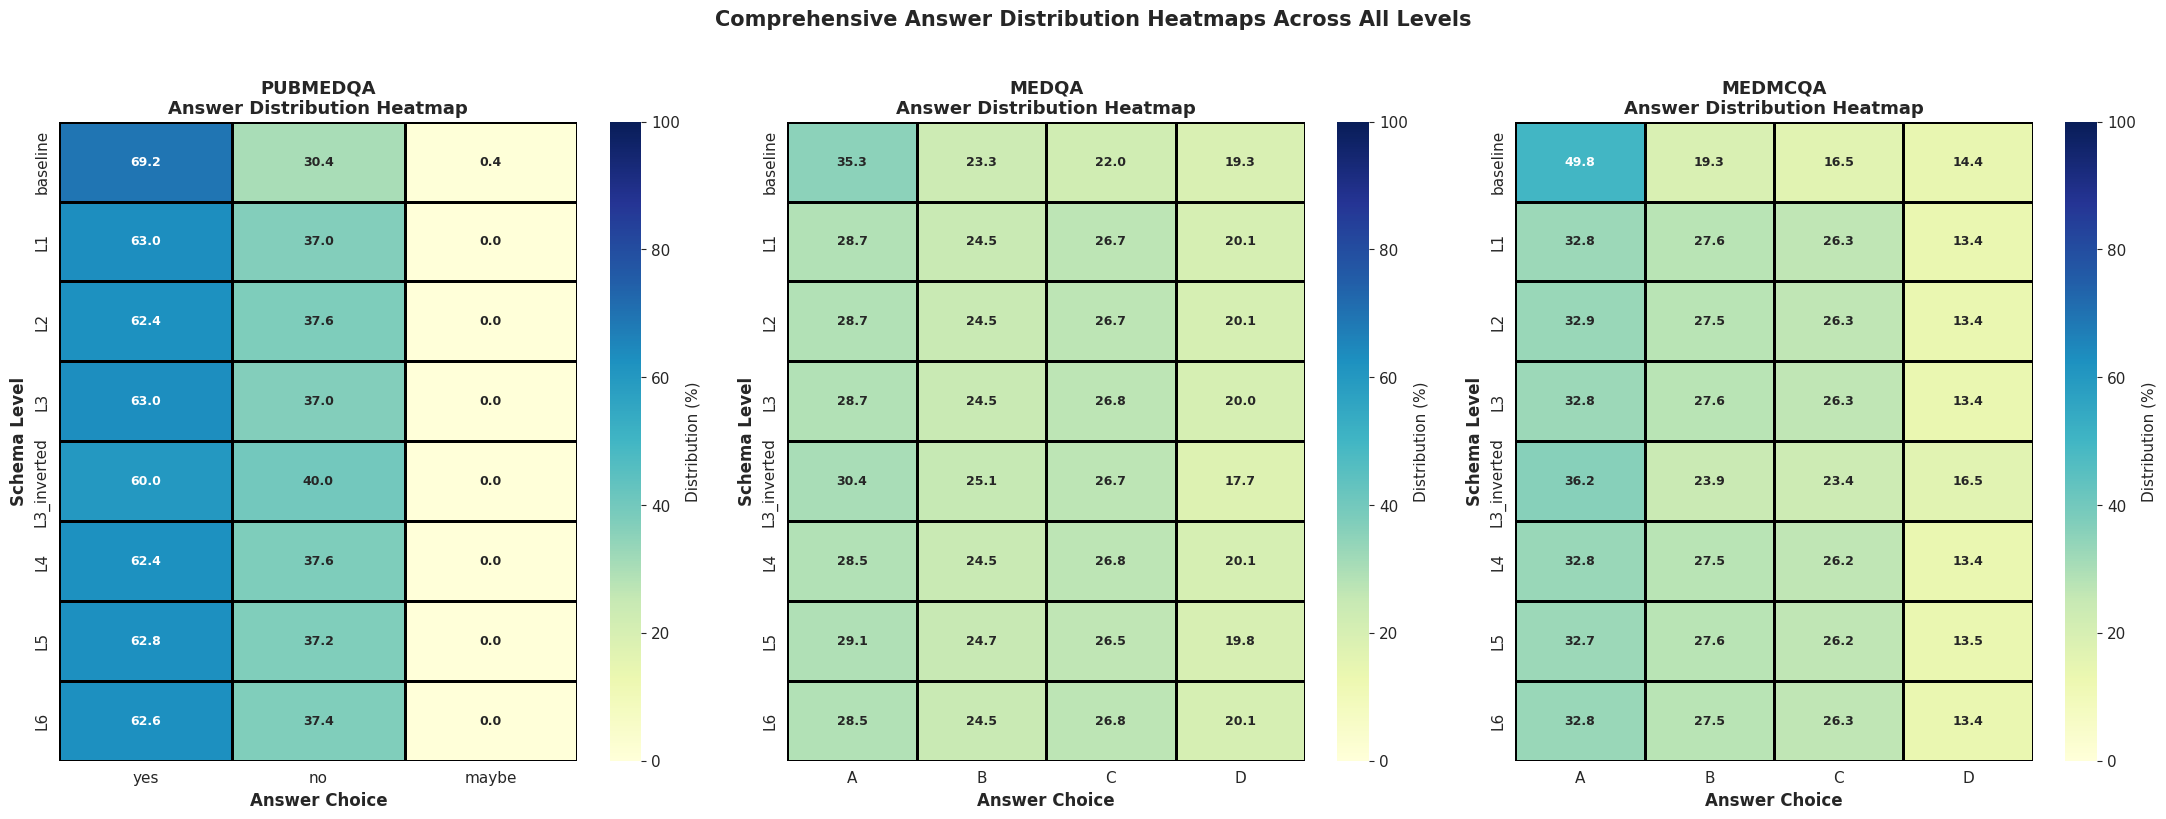

In [29]:
# Step 3: Create comprehensive heatmaps showing distributions across all (benchmark × level × answer_choice)

# Create a unified heatmap showing all distributions
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_dist = [d for d in comprehensive_distribution_data if d['benchmark'] == benchmark]
    
    if not bench_dist:
        continue
    
    valid_answers = bench_dist[0]['valid_answers']
    # Sort levels: baseline first, then L1-L6, then L3_inverted
    level_order = ['baseline', 'L1', 'L2', 'L3', 'L3_inverted', 'L4', 'L5', 'L6']
    levels = [l for l in level_order if any(d['level'] == l for d in bench_dist)]
    
    # Create matrix
    dist_matrix = []
    for level in levels:
        dist_item = next((d for d in bench_dist if d['level'] == level), None)
        if dist_item:
            dist = [dist_item['distribution'].get(a, 0) for a in valid_answers]
            dist_matrix.append(dist)
        else:
            dist_matrix.append([0] * len(valid_answers))
    
    dist_matrix = np.array(dist_matrix)
    
    sns.heatmap(dist_matrix, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=levels,
                cbar_kws={'label': 'Distribution (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    ax.set_xlabel('Answer Choice', fontsize=12, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=12, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Distribution Heatmap', fontsize=13, fontweight='bold')

plt.suptitle('Comprehensive Answer Distribution Heatmaps Across All Levels', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comprehensive_distribution_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


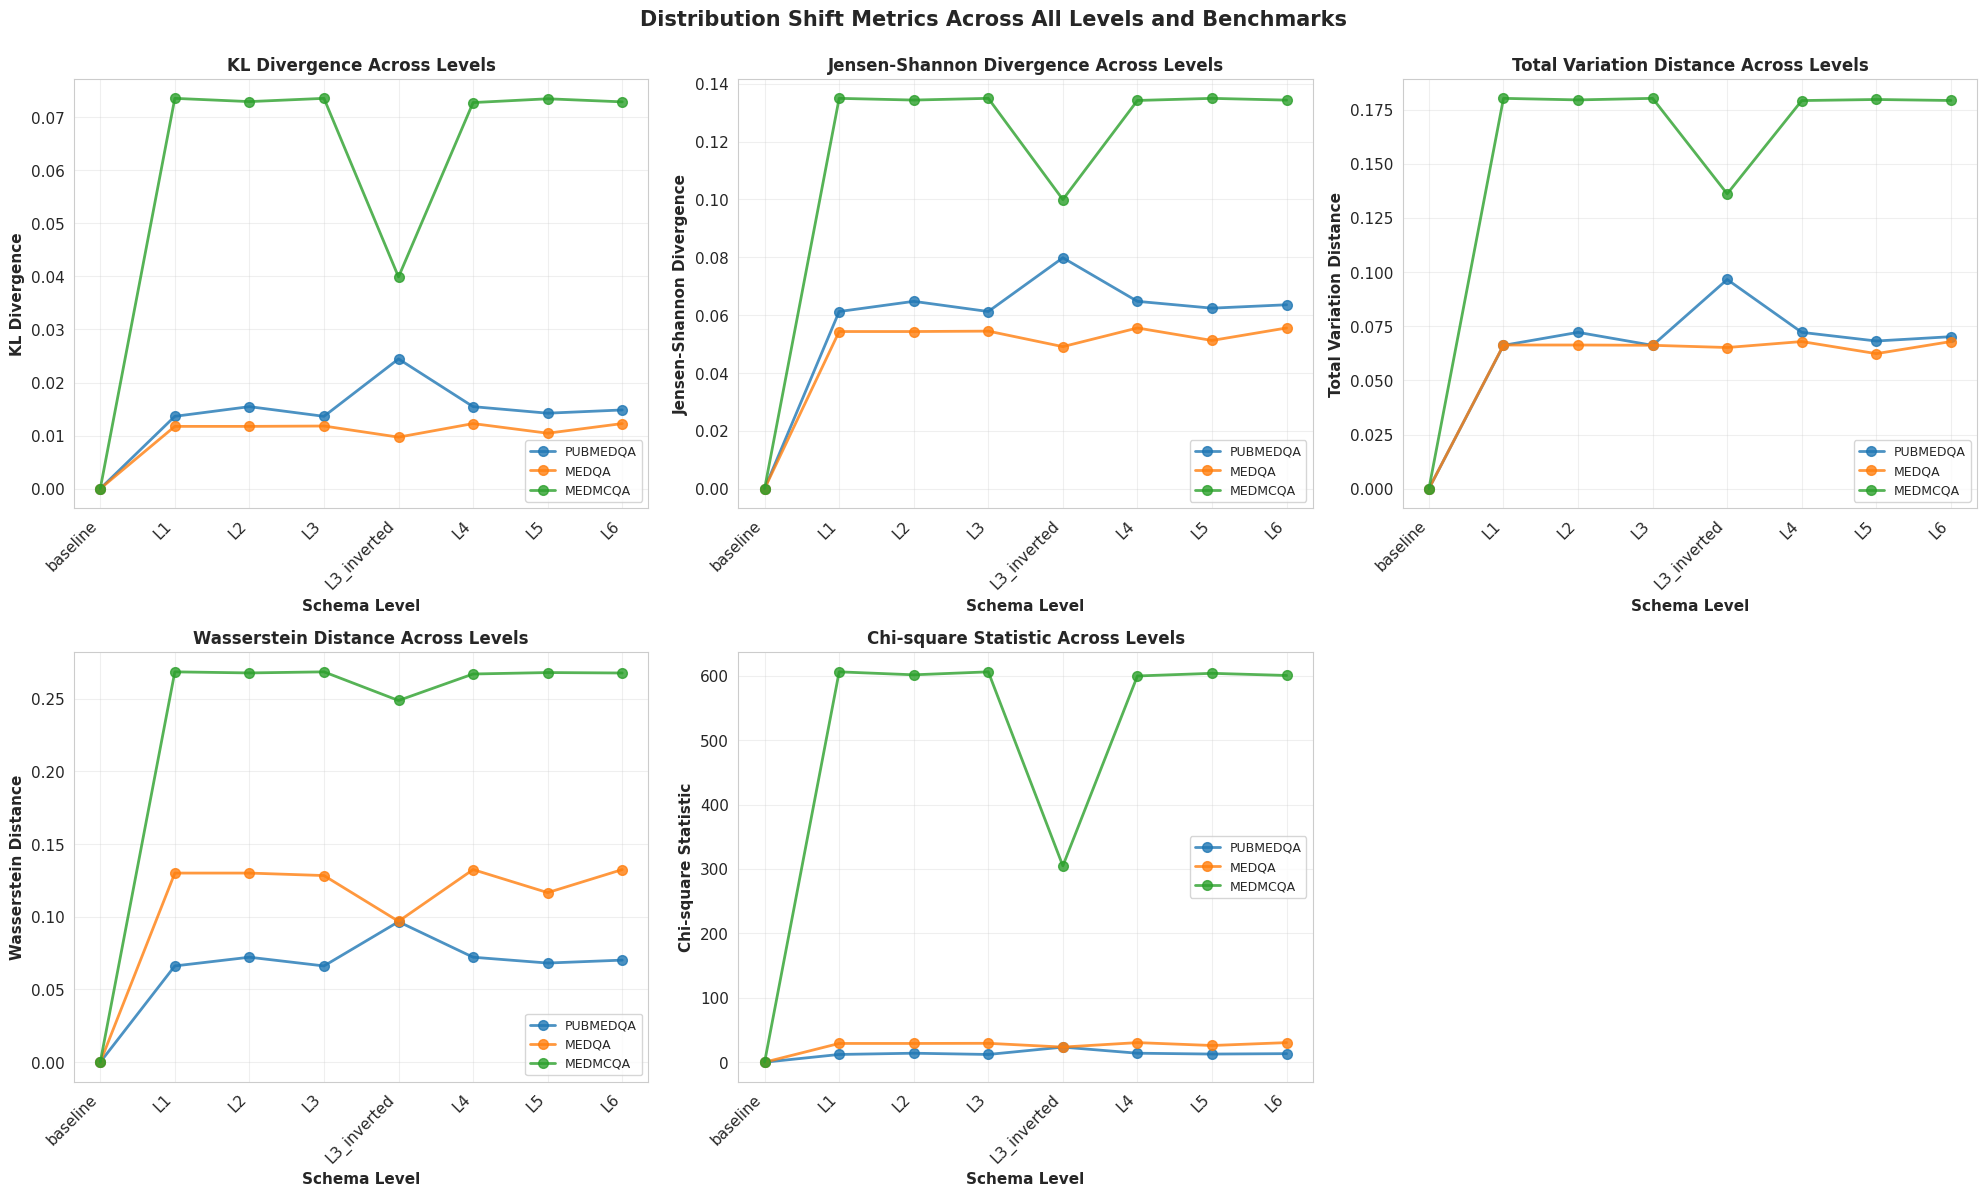

In [30]:
# Step 4: Create line plots and bar charts showing all distribution shift metrics across levels

# Define level order for consistent plotting
level_order = ['baseline', 'L1', 'L2', 'L3', 'L3_inverted', 'L4', 'L5', 'L6']

# Create multi-panel figure showing all metrics
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

metrics_to_plot = [
    ('kl_divergence', 'KL Divergence', 'steelblue'),
    ('jensen_shannon', 'Jensen-Shannon Divergence', 'darkgreen'),
    ('total_variation', 'Total Variation Distance', 'coral'),
    ('wasserstein', 'Wasserstein Distance', 'purple'),
    ('chi2_statistic', 'Chi-square Statistic', 'darkred'),
]

for metric_idx, (metric_col, metric_name, color) in enumerate(metrics_to_plot):
    row = metric_idx // 3
    col = metric_idx % 3
    ax = axes[row, col]
    
    for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
        bench_data = comprehensive_dist_df[comprehensive_dist_df['benchmark'] == benchmark].copy()
        if len(bench_data) == 0:
            continue
        
        # Sort by level order
        bench_data['level_num'] = bench_data['level'].map({l: i for i, l in enumerate(level_order) 
                                                           if l in bench_data['level'].values})
        bench_data = bench_data.sort_values('level_num')
        
        levels = bench_data['level'].values
        values = bench_data[metric_col].values
        
        # Filter out NaN values for plotting
        valid_mask = ~np.isnan(values)
        if valid_mask.sum() > 0:
            ax.plot(np.arange(len(levels))[valid_mask], values[valid_mask], 
                   marker='o', linewidth=2, markersize=7, label=benchmark.upper(), alpha=0.8)
    
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name} Across Levels', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len([l for l in level_order if l in comprehensive_dist_df['level'].values])))
    ax.set_xticklabels([l for l in level_order if l in comprehensive_dist_df['level'].values], 
                       rotation=45, ha='right')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].axis('off')

plt.suptitle('Distribution Shift Metrics Across All Levels and Benchmarks', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comprehensive_shift_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


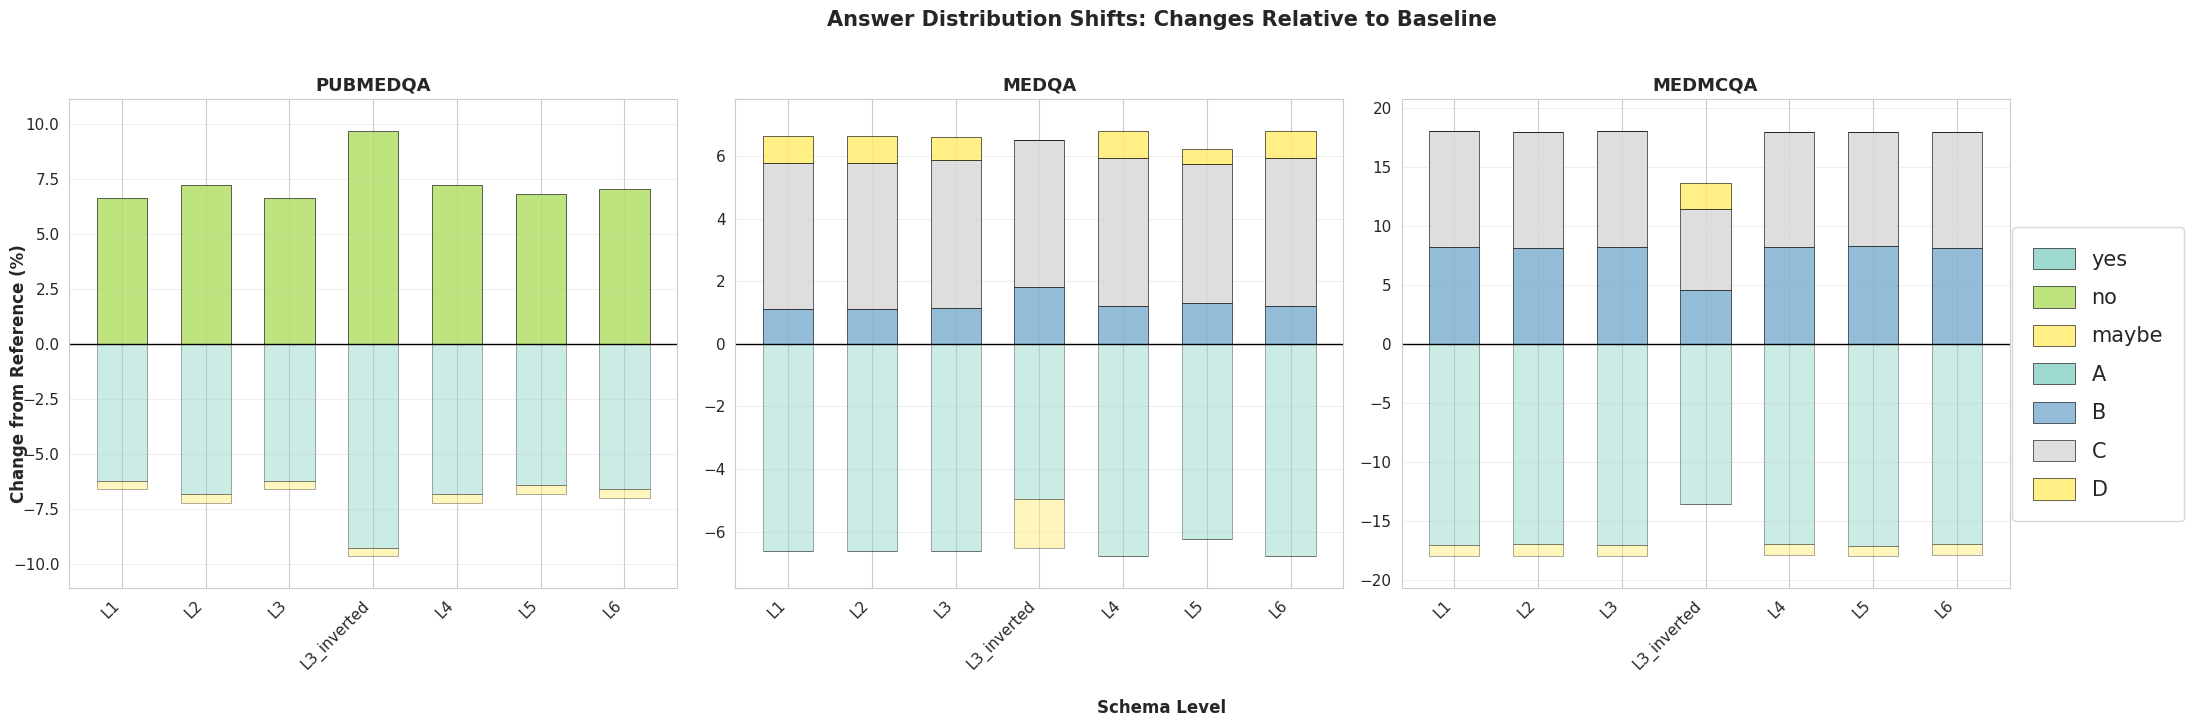

In [38]:
# Step 5: Answer distribution shift directions (stacked, +/- around 0) with one clean legend
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# We'll build ONE legend: answer -> handle
legend_handles = {}

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]

    # Reference distribution
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    ref_item = next(
        (d for d in comprehensive_distribution_data
         if d['benchmark'] == benchmark and d['level'] == reference_level),
        None
    )
    if not ref_item:
        continue

    valid_answers = ref_item['valid_answers']
    ref_dist = ref_item['distribution']

    # Levels to plot (exclude reference)
    levels = [l for l in level_order if l in all_parsed[benchmark].keys() and l != reference_level]

    # Prepare shifts
    shifts_data = {ans: [] for ans in valid_answers}
    level_labels = []

    for level in levels:
        level_item = next(
            (d for d in comprehensive_distribution_data
             if d['benchmark'] == benchmark and d['level'] == level),
            None
        )
        if not level_item:
            continue

        level_labels.append(level)
        level_dist = level_item['distribution']

        for ans in valid_answers:
            shifts_data[ans].append(level_dist.get(ans, 0) - ref_dist.get(ans, 0))

    # X axis
    x = np.arange(len(level_labels))
    width = 0.6
    bottom_positive = np.zeros(len(level_labels))
    bottom_negative = np.zeros(len(level_labels))

    # Pastel categorical palette
    colors = plt.cm.Set3(np.linspace(0, 1, len(valid_answers)))

    for i, ans in enumerate(valid_answers):
        shifts = np.array(shifts_data[ans], dtype=float)
        pos = np.where(shifts > 0, shifts, 0.0)
        neg = np.where(shifts < 0, shifts, 0.0)

        # Positive bars (same color, higher alpha)
        if pos.sum() > 0:
            bars_pos = ax.bar(
                x, pos, width,
                bottom=bottom_positive,
                color=colors[i],
                alpha=0.85,
                edgecolor='black',
                linewidth=0.5
            )
            bottom_positive += pos

            # Register a SINGLE legend handle for this answer (use the positive handle)
            legend_handles.setdefault(ans, bars_pos[0])

        # Negative bars (same color, lower alpha)
        if neg.sum() < 0:
            ax.bar(
                x, neg, width,
                bottom=bottom_negative,
                color=colors[i],
                alpha=0.45,
                edgecolor='black',
                linewidth=0.5
            )
            bottom_negative += neg

            # If answer never appeared in positive, still register a handle
            if ans not in legend_handles:
                # create a tiny dummy bar handle (invisible) just for legend
                dummy = ax.bar([np.nan], [np.nan], color=colors[i], alpha=0.85,
                               edgecolor='black', linewidth=0.5)
                legend_handles[ans] = dummy[0]

    # Symmetric y-limits with padding (prevents clipping)
    max_pos = np.max(bottom_positive) if len(bottom_positive) > 0 else 0
    max_neg = np.min(bottom_negative) if len(bottom_negative) > 0 else 0
    ylim = max(abs(max_pos), abs(max_neg)) * 1.15 if max(abs(max_pos), abs(max_neg)) > 0 else 1
    ax.set_ylim(-ylim, ylim)

    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{benchmark.upper()}', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(level_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Shared axis labels
fig.supxlabel("Schema Level", fontsize=12, fontweight="bold")
fig.supylabel("Change from Reference (%)", fontsize=12, fontweight="bold")

# Bigger legend: larger font + larger color swatches
fig.legend(
    handles=list(legend_handles.values()),
    labels=list(legend_handles.keys()),
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),  
    fontsize=15,                 # increase legend text size
    frameon=True,
    handlelength=2.0,            
    handleheight=1.2,
    borderpad=1.0,
    labelspacing=0.8
)

plt.suptitle(
    'Answer Distribution Shifts: Changes Relative to Baseline',
    fontsize=15, fontweight='bold', y=1.02
)

# Leave room on the right for the legend (tune rect[2])
plt.tight_layout(rect=[0, 0, 0.86, 1])

plt.savefig(PLOTS_DIR / 'distribution_shift_directions.png', dpi=300, bbox_inches='tight')
plt.show()


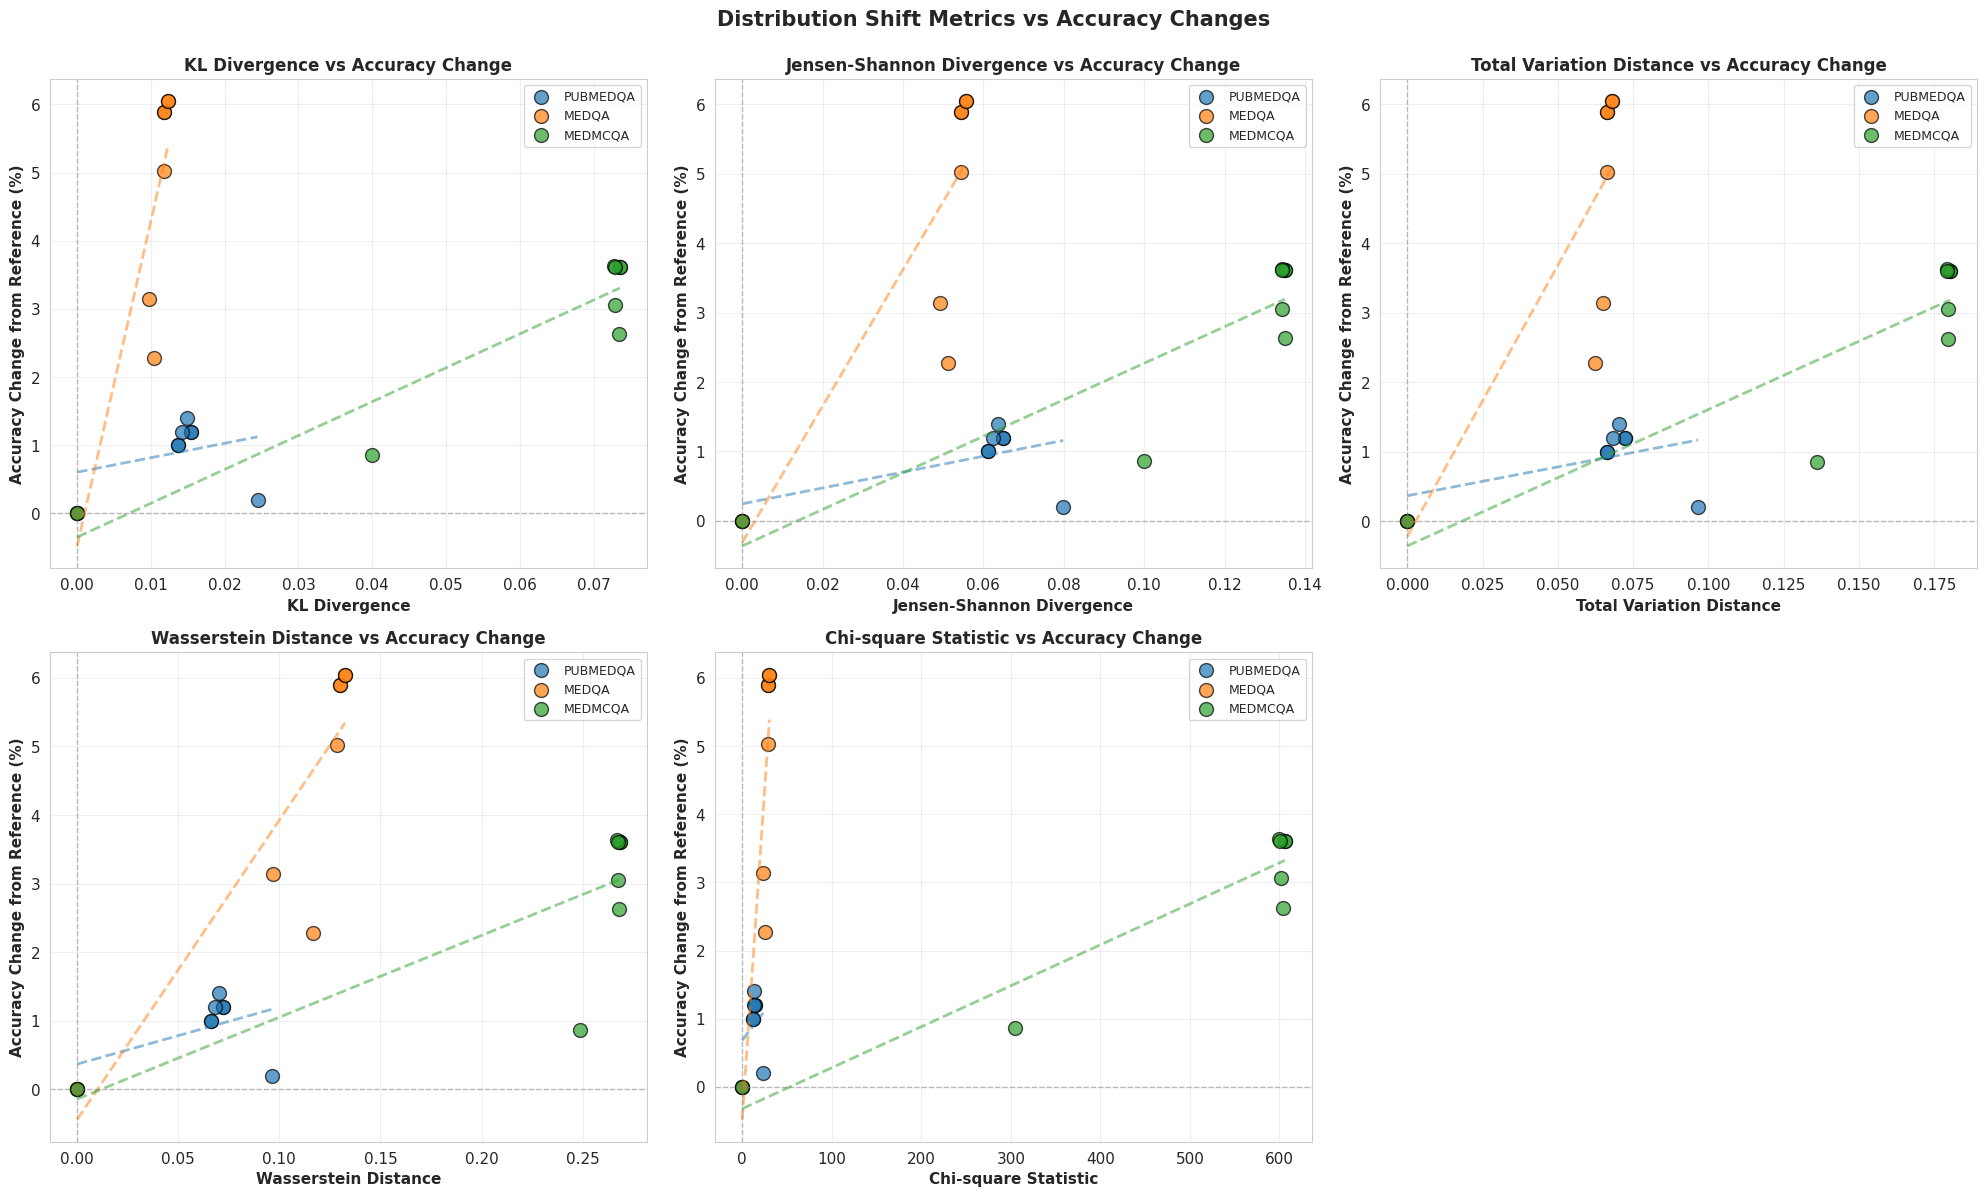


Correlation Analysis: Distribution Shifts vs Accuracy Changes
KL Divergence                 : r = +0.204 (n=24)
Jensen-Shannon Divergence     : r = +0.283 (n=24)
Total Variation Distance      : r = +0.293 (n=24)
Wasserstein Distance          : r = +0.458 (n=24)
Chi-square Statistic          : r = +0.204 (n=24)


In [34]:
# Step 6: Analyze relationships between distribution shifts and accuracy changes

# Merge distribution metrics with accuracy data
shift_performance_df = comprehensive_dist_df.merge(
    accuracy_df[['benchmark', 'level', 'accuracy']], 
    on=['benchmark', 'level'], 
    how='inner'
)

# Calculate accuracy change from reference
shift_performance_df['accuracy_change'] = np.nan
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = shift_performance_df[shift_performance_df['benchmark'] == benchmark].copy()
    reference_level = 'baseline' if 'baseline' in bench_data['level'].values else 'L1'
    ref_acc = bench_data[bench_data['level'] == reference_level]['accuracy'].values[0] if len(bench_data[bench_data['level'] == reference_level]) > 0 else None
    
    if ref_acc is not None:
        mask = shift_performance_df['benchmark'] == benchmark
        shift_performance_df.loc[mask, 'accuracy_change'] = (
            shift_performance_df.loc[mask, 'accuracy'] - ref_acc
        ) * 100

# Create scatter plots: distribution shift metrics vs accuracy change
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

metrics_for_correlation = [
    ('kl_divergence', 'KL Divergence'),
    ('jensen_shannon', 'Jensen-Shannon Divergence'),
    ('total_variation', 'Total Variation Distance'),
    ('wasserstein', 'Wasserstein Distance'),
    ('chi2_statistic', 'Chi-square Statistic'),
]

for metric_idx, (metric_col, metric_name) in enumerate(metrics_for_correlation):
    row = metric_idx // 3
    col = metric_idx % 3
    ax = axes[row, col]
    
    for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
        bench_data = shift_performance_df[
            (shift_performance_df['benchmark'] == benchmark) & 
            (~np.isnan(shift_performance_df[metric_col])) &
            (~np.isnan(shift_performance_df['accuracy_change']))
        ].copy()
        
        if len(bench_data) > 0:
            ax.scatter(bench_data[metric_col], bench_data['accuracy_change'], 
                      label=benchmark.upper(), alpha=0.7, s=100, edgecolors='black', linewidth=1)
            
            # Add regression line
            if len(bench_data) > 1:
                z = np.polyfit(bench_data[metric_col], bench_data['accuracy_change'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(bench_data[metric_col].min(), bench_data[metric_col].max(), 100)
                ax.plot(x_line, p(x_line), '--', alpha=0.5, linewidth=2)
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy Change from Reference (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name} vs Accuracy Change', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].axis('off')

plt.suptitle('Distribution Shift Metrics vs Accuracy Changes', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shift_vs_accuracy_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute correlation coefficients
print("\nCorrelation Analysis: Distribution Shifts vs Accuracy Changes")
print("="*80)
for metric_col, metric_name in metrics_for_correlation:
    valid_data = shift_performance_df[
        (~np.isnan(shift_performance_df[metric_col])) &
        (~np.isnan(shift_performance_df['accuracy_change']))
    ]
    if len(valid_data) > 1:
        corr = np.corrcoef(valid_data[metric_col], valid_data['accuracy_change'])[0, 1]
        print(f"{metric_name:30s}: r = {corr:+.3f} (n={len(valid_data)})")


In [35]:
# Step 7: Identify optimal levels with best balance of distribution shift and performance

# Create a composite score: balance between shift magnitude and accuracy improvement
# Higher shift + higher accuracy improvement = better

optimal_levels_analysis = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = shift_performance_df[shift_performance_df['benchmark'] == benchmark].copy()
    
    if len(bench_data) == 0:
        continue
    
    # Normalize metrics to 0-1 scale for comparison
    for metric_col in ['kl_divergence', 'jensen_shannon', 'total_variation', 'wasserstein', 'chi2_statistic']:
        valid_values = bench_data[metric_col].dropna()
        if len(valid_values) > 0:
            min_val = valid_values.min()
            max_val = valid_values.max()
            if max_val > min_val:
                bench_data[f'{metric_col}_norm'] = (bench_data[metric_col] - min_val) / (max_val - min_val)
            else:
                bench_data[f'{metric_col}_norm'] = 0
    
    # Normalize accuracy change
    acc_changes = bench_data['accuracy_change'].dropna()
    if len(acc_changes) > 0:
        min_acc = acc_changes.min()
        max_acc = acc_changes.max()
        if max_acc > min_acc:
            bench_data['accuracy_change_norm'] = (bench_data['accuracy_change'] - min_acc) / (max_acc - min_acc)
        else:
            bench_data['accuracy_change_norm'] = 0
    
    # Composite score: weighted combination of shift magnitude and accuracy improvement
    # Use Jensen-Shannon as primary shift metric (symmetric, bounded)
    if 'jensen_shannon_norm' in bench_data.columns:
        bench_data['composite_score'] = (
            0.4 * bench_data['jensen_shannon_norm'].fillna(0) +
            0.6 * bench_data['accuracy_change_norm'].fillna(0)
        )
    else:
        bench_data['composite_score'] = bench_data['accuracy_change_norm'].fillna(0)
    
    # Find best levels
    best_composite = bench_data.loc[bench_data['composite_score'].idxmax()] if len(bench_data) > 0 else None
    best_accuracy = bench_data.loc[bench_data['accuracy_change'].idxmax()] if len(bench_data) > 0 else None
    max_shift = bench_data.loc[bench_data['jensen_shannon'].idxmax()] if 'jensen_shannon' in bench_data.columns and len(bench_data) > 0 else None
    
    optimal_levels_analysis.append({
        'benchmark': benchmark,
        'best_composite_level': best_composite['level'] if best_composite is not None else None,
        'best_composite_score': best_composite['composite_score'] if best_composite is not None else None,
        'best_accuracy_level': best_accuracy['level'] if best_accuracy is not None else None,
        'best_accuracy_change': best_accuracy['accuracy_change'] if best_accuracy is not None else None,
        'max_shift_level': max_shift['level'] if max_shift is not None else None,
        'max_shift_value': max_shift['jensen_shannon'] if max_shift is not None else None,
    })
    
    # L3 vs L3_inverted comparison
    l3_data = bench_data[bench_data['level'] == 'L3']
    l3_inv_data = bench_data[bench_data['level'] == 'L3_inverted']
    
    if len(l3_data) > 0 and len(l3_inv_data) > 0:
        l3_acc = l3_data['accuracy_change'].values[0]
        l3_inv_acc = l3_inv_data['accuracy_change'].values[0]
        l3_shift = l3_data['jensen_shannon'].values[0] if 'jensen_shannon' in l3_data.columns else np.nan
        l3_inv_shift = l3_inv_data['jensen_shannon'].values[0] if 'jensen_shannon' in l3_inv_data.columns else np.nan
        
        print(f"\n{benchmark.upper()} - L3 vs L3_inverted Comparison:")
        print(f"  L3:           Accuracy change = {l3_acc:+.2f}%, Shift (JS) = {l3_shift:.4f}")
        print(f"  L3_inverted:  Accuracy change = {l3_inv_acc:+.2f}%, Shift (JS) = {l3_inv_shift:.4f}")
        print(f"  Difference:   Accuracy = {l3_inv_acc - l3_acc:+.2f}%, Shift = {l3_inv_shift - l3_shift:+.4f}")

optimal_levels_df = pd.DataFrame(optimal_levels_analysis)

print("\n" + "="*80)
print("OPTIMAL LEVEL IDENTIFICATION")
print("="*80)
print(optimal_levels_df.to_string(index=False))



PUBMEDQA - L3 vs L3_inverted Comparison:
  L3:           Accuracy change = +1.00%, Shift (JS) = 0.0613
  L3_inverted:  Accuracy change = +0.20%, Shift (JS) = 0.0798
  Difference:   Accuracy = -0.80%, Shift = +0.0186

MEDQA - L3 vs L3_inverted Comparison:
  L3:           Accuracy change = +5.03%, Shift (JS) = 0.0545
  L3_inverted:  Accuracy change = +3.14%, Shift (JS) = 0.0491
  Difference:   Accuracy = -1.89%, Shift = -0.0054

MEDMCQA - L3 vs L3_inverted Comparison:
  L3:           Accuracy change = +3.61%, Shift (JS) = 0.1350
  L3_inverted:  Accuracy change = +0.86%, Shift (JS) = 0.1000
  Difference:   Accuracy = -2.75%, Shift = -0.0350

OPTIMAL LEVEL IDENTIFICATION
benchmark best_composite_level  best_composite_score best_accuracy_level  best_accuracy_change max_shift_level  max_shift_value
 pubmedqa                   L6              0.918592                  L6              1.400000     L3_inverted         0.079848
    medqa                   L4              1.000000               

## Cross-Benchmark Summary

This section provides a comprehensive summary of key findings across all benchmarks and evaluation points.


In [38]:
# Create summary tables
print("="*100)
print("CROSS-BENCHMARK SUMMARY")
print("="*100)

# 1. Accuracy Summary
print("\n1. ACCURACY UNDER STRUCTURED CONSTRAINTS")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'Accuracy (%)':<15} {'Change from Ref (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    # Get reference
    reference = 'baseline' if 'baseline' in bench_data['level'].values else 'L1'
    ref_acc = bench_data[bench_data['level'] == reference]['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == reference]) > 0 else None
    
    for _, row in bench_data.iterrows():
        level = row['level']
        acc = row['accuracy'] * 100
        change = (acc - ref_acc) if ref_acc is not None else 0
        change_str = f"{change:+.2f}" if ref_acc is not None else "N/A"
        print(f"{benchmark.upper():<15} {level:<10} {acc:<15.2f} {change_str:<20}")

# 2. Compliance Summary
print("\n2. OUTPUT VALIDITY AND SCHEMA COMPLIANCE")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'JSON Valid (%)':<18} {'Schema Compliant (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        json_valid = row['json_valid_rate'] * 100
        schema_compliant = row['schema_compliant_rate'] * 100
        print(f"{benchmark.upper():<15} {level:<10} {json_valid:<18.2f} {schema_compliant:<20.2f}")

# 3. Calibration Summary
print("\n3. CONFIDENCE AND CALIBRATION BEHAVIOR")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'ECE':<10} {'Correlation':<15} {'Mean Confidence':<18}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        ece = row['ece']
        corr = row['correlation']
        mean_conf = row['mean_confidence']
        print(f"{benchmark.upper():<15} {level:<10} {ece:<10.3f} {corr:<15.3f} {mean_conf:<18.3f}")

# 4. Distribution Shift Summary
print("\n4. DECISION DISTRIBUTION SHIFTS")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'KL Divergence':<18} {'Chi2 Statistic':<18}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = distribution_df[distribution_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        kl_div = row['kl_divergence']
        chi2 = row['chi2_statistic']
        kl_str = f"{kl_div:.3f}" if not np.isnan(kl_div) else "N/A"
        chi2_str = f"{chi2:.3f}" if not np.isnan(chi2) else "N/A"
        print(f"{benchmark.upper():<15} {level:<10} {kl_str:<18} {chi2_str:<18}")

print("\n" + "="*100)


CROSS-BENCHMARK SUMMARY

1. ACCURACY UNDER STRUCTURED CONSTRAINTS
----------------------------------------------------------------------------------------------------
Benchmark       Level      Accuracy (%)    Change from Ref (%) 
----------------------------------------------------------------------------------------------------
PUBMEDQA        L1         77.20           +0.00               
PUBMEDQA        L2         77.40           +0.20               
PUBMEDQA        L3         77.20           +0.00               
PUBMEDQA        L4         77.40           +0.20               
PUBMEDQA        L5         77.40           +0.20               
PUBMEDQA        L6         77.60           +0.40               
MEDQA           L1         62.14           +5.89               
MEDQA           L2         62.14           +5.89               
MEDQA           L3         61.27           +5.03               
MEDQA           L4         62.29           +6.05               
MEDQA           L5         5